In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"


In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os

root_address = '/home/nima/drive/computer_vision/activity/5/code'

for dirname, _, filenames in os.walk(root_address):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/home/nima/drive/computer_vision/activity/5/code/activity_5_2.ipynb
/home/nima/drive/computer_vision/activity/5/code/sartorius-cell-instance-segmentation.zip
/home/nima/drive/computer_vision/activity/5/code/activity_5_1.ipynb


# Import Libraries

In [3]:
import os
import time
import random
import collections
from pathlib import Path
from tqdm.notebook import tqdm 
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cv2
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader 

import torchvision
from torchvision.transforms import functional as F
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor 
from torchvision.transforms.functional import to_pil_image

import warnings
warnings.filterwarnings("ignore")


In [4]:
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA avaliable: {torch.cuda.is_available()}')


PyTorch version: 2.0.0.post304
CUDA avaliable: True


In [5]:
folder_name = 'sartorius-cell-instance-segmentation'
zip_file_name = 'sartorius-cell-instance-segmentation.zip'

# Check if the folder already exists
if os.path.isdir(folder_name):
    print(f"The folder '{folder_name}' already exists.")
elif os.path.exists(zip_file_name):
    # If the folder doesn't exist, unzip the file
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall(folder_name)
    print(f"Unzipped '{zip_file_name}' into '{folder_name}' folder.")
else: 
    print(f"'{zip_file_name}' file is required") 


Unzipped 'sartorius-cell-instance-segmentation.zip' into 'sartorius-cell-instance-segmentation' folder.


# Fix Randomness

In [6]:
def fix_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # torch.backends.cudnn.deterministic = True
    # torch.backends.cudnn.benchmark = True
    
    os.environ['PYTHONHASHSEED'] = str(seed)


# Set seed
fix_all_seeds(2023)


In [7]:
os.getcwd()


'/home/nima/drive/computer_vision/activity/5/code'

# Configurations

In [8]:
# Directory setting
DATA_DIR = root_address + '/sartorius-cell-instance-segmentation/'

TRAIN_CSV = DATA_DIR + 'train.csv'
TRAIN_PATH = DATA_DIR + 'train/'
TEST_PATH = DATA_DIR + 'test/'

NORMALIZE = False                         # Normalize to resnet mean and std if True. Be set in transforms().
RESNET_MEAN = (0.485, 0.456, 0.406)
RESNET_STD = (0.229, 0.224, 0.225)
IMG_SIZE = (224, 224)                     # size of resized image for model input
HEIGHT = 520                              # height of the provided train image
WIDTH = 704                               # width of the provided train image

H_LAYER = 256
BOX_DETECTIONS_PER_IMG = 790
MIN_SCORE = 0.59
MASK_THRESHOLD = 0.5   # Changes the confidence required for a pixel to be kept for a mask. Only used 0.5 till now.


BATCH_SIZE = 8
BATCH_SHUFFLE = True
EPOCHS = 18

USE_SCHEDULER = False  # Use a StepLR scheduler if True. Not tried yet.
MOMENTUM = 0.95
LEARNING_RATE = 0.001
WEIGHT_DECAY = 0.0005

# CELL_TYPES  = {0: 'shsy5y', 1: 'astro', 2: 'cort'}
CLASSES_NUM = 4        # 3 types of cell + 1 type as background

## Set device
DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f'Using {DEVICE} device')


Using cuda device


# Helper Functions and Classes

## Transformation Classes

In [9]:
class Compose():
    def __init__(self, transforms):
        self.transforms = transforms
    
    
    def __call__(self, image, target):
        for t in self.transforms:
            image, target = t(image, target)
        
        return image, target

    
    

class VerticalFlip():
    def __init__(self, prob):
        self.prob = prob
    
    
    def __call__(self, image, target):
        if random.random() < self.prob:                  # 实现 VerticalFlip 的概率小于初始化的 prob
            height, weight = image.shape[-2:]
            image = image.flip(-2)
            bbox = target["boxes"]
            bbox[:, [1, 3]] = height - bbox[:, [3, 1]]   # 因为 image.flip(-2) 将图片 vertical flip 了，所以相应的 bbox 的范围要做这番调整。
            target["boxes"] = bbox
            target["masks"] = target["masks"].flip(-2)
        return image, target

    
    

class HorizontalFlip():
    def __init__(self, prob):
        self.prob = prob

    def __call__(self, image, target):
        if random.random() < self.prob:                # 实现 VerticalFlip 的概率小于初始化的 prob
            height, width = image.shape[-2:]
            image = image.flip(-1)
            bbox = target["boxes"]
            bbox[:, [0, 2]] = width - bbox[:, [2, 0]]  # 因为 image.flip(-1) 将图片 horizontal flip 了，所以相应的 bbox 的范围要做这番调整。
            target["boxes"] = bbox
            target["masks"] = target["masks"].flip(-1)
        return image, target



class Normalize():
    def __call__(self, image, target):
        image = F.normalize(image, RESNET_MEAN, RESNET_STD)
        return image, target



class ToTensor():
    def __call__(self, image, target):
        image = F.to_tensor(image)
        return image, target

class Resize():
    def __call__(self, image, target):
        image = F.resize(image, IMG_SIZE)
        return image, target


## transforms()

In [10]:
def transforms(train=True):
    transforms = [ToTensor()]
    
    if NORMALIZE:        # Set to False in Configurations, cause it can be achieved in params of MRcnn.
        transforms.append(Normalize())
    
    # Data augmentation for training
    if train: 
        transforms.append(HorizontalFlip(0.5))
        transforms.append(VerticalFlip(0.5))

    return Compose(transforms)


## show_gpu_memory()

In [11]:
def show_gpu_memory(device):
    print(f"Allocated GPU memory: {torch.cuda.memory_allocated(device) / 1024 / 1024:.2f} MB")
    print(f"Cached GPU memory: {torch.cuda.memory_cached(device) / 1024 / 1024:.2f} MB") 

show_gpu_memory(DEVICE)

Allocated GPU memory: 0.00 MB
Cached GPU memory: 0.00 MB


In [12]:
torch.cuda.get_device_properties(DEVICE)


_CudaDeviceProperties(name='NVIDIA GeForce RTX 3090', major=8, minor=6, total_memory=24251MB, multi_processor_count=82)

## rle_decode()

In [13]:
def rle_decode(rle, img_shape, color=1):
    """Decode the RLE (annotation) of an particular cell instance in an image to its correspongding mask.

    Args:
        rle (str): mask with run length encoding.
        img_shape ((int, int)): (height, width) of the image, also the shape of mask np.ndarray to return.
        color (int): brightness of the mask pixel. Default to 1.

    Returns:
        np.ndarray: 1 - mask, 0 - background.
    """
    rle_list = rle.split()
    starts, lengths = [np.asarray(x, dtype=int) for x in (rle_list[0:][::2], rle_list[1:][::2])]
    starts -= 1
    ends = starts + lengths
    
    mask = np.zeros(img_shape[0] * img_shape[1], dtype=np.float32)
    for lo, hi in zip(starts, ends):
        mask[lo:hi] = color
    
    return mask.reshape(img_shape)


## build_image_mask()

In [14]:
def build_image_mask(img, rle_list):
    """Decode RLEs (annotations) of all cell instance in an image into one mask image.
    
    Args:
        img (np.ndarray): image with single channel or multiple channels.
        rle_list (list of str): rles of all cell instances in an image as a list.
    
    Returns:
        np.ndarray: 1 - mask, 0 - background.
    """
    img_shape = img.shape
    h = img_shape[0]
    w = img_shape[1]
    
    mask = np.zeros((h, w))
    for rle in rle_list:
        mask += rle_decode(rle, (h, w))
    mask = mask.clip(0,1)
    
    return mask


# EDA (Exploratory Data Analysis)

## Explore

In [15]:
df_train = pd.read_csv(TRAIN_CSV)
df_train.head() 
df_train.tail() 


,id,annotation,width,height,cell_type,plate_time,sample_date,sample_id,elapsed_timedelta
0,0030fd0e6378,118145 6 118849 7 119553 8 120257 8 120961 9 1...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
1,0030fd0e6378,189036 1 189739 3 190441 6 191144 7 191848 8 1...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
2,0030fd0e6378,173567 3 174270 5 174974 5 175678 6 176382 7 1...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
3,0030fd0e6378,196723 4 197427 6 198130 7 198834 8 199538 8 2...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
4,0030fd0e6378,167818 3 168522 5 169225 7 169928 8 170632 9 1...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00


,id,annotation,width,height,cell_type,plate_time,sample_date,sample_id,elapsed_timedelta
73580,ffdb3cc02eef,3610 3 4311 7 5014 9 5717 11 6420 13 7123 15 7...,704,520,cort,11h59m00s,2020-11-01,cort[debris]_D9-3_Vessel-384_Ph_4,0 days 11:59:00
73581,ffdb3cc02eef,341585 2 342287 5 342988 10 343690 13 344394 1...,704,520,cort,11h59m00s,2020-11-01,cort[debris]_D9-3_Vessel-384_Ph_4,0 days 11:59:00
73582,ffdb3cc02eef,47788 3 48490 7 49192 11 49896 13 50599 14 513...,704,520,cort,11h59m00s,2020-11-01,cort[debris]_D9-3_Vessel-384_Ph_4,0 days 11:59:00
73583,ffdb3cc02eef,333290 1 333993 2 334696 4 335399 5 336102 6 3...,704,520,cort,11h59m00s,2020-11-01,cort[debris]_D9-3_Vessel-384_Ph_4,0 days 11:59:00
73584,ffdb3cc02eef,249775 2 250477 6 251180 8 251882 11 252585 12...,704,520,cort,11h59m00s,2020-11-01,cort[debris]_D9-3_Vessel-384_Ph_4,0 days 11:59:00


In [16]:
df_train.shape


(73585, 9)

In [17]:
df_train.dtypes


id                   object
annotation           object
width                 int64
height                int64
cell_type            object
plate_time           object
sample_date          object
sample_id            object
elapsed_timedelta    object
dtype: object

## Cell Type

In [18]:
df_train.cell_type.value_counts() 


cell_type
shsy5y    52286
cort      10777
astro     10522
Name: count, dtype: int64

## Annotation (RLE)

In [19]:
# train.csv 中 id 列是图片编号，每一行的 annotation 都是该图片中的一个细胞实例的 mask 数据。
# 若一张图片中有 395 个细胞实例的 mask，则这张图片会在表格中出现 395 行。
df_instances = df_train.groupby(['id']).agg({'annotation': 'count', 'cell_type': 'first'})
df_instances.head()


,annotation,cell_type
id,,
0030fd0e6378,395,shsy5y
0140b3c8f445,108,astro
01ae5a43a2ab,36,cort
026b3c2c4b32,42,cort
029e5b3b89c7,34,cort


In [20]:
df_instances.shape 


(606, 2)

In [21]:
# 每一种细胞类型（一张图片只有一种细胞）它在一张图片中 instance segmentation mask
# (亦即表中对应图片的 annotation 行数) 的总数的分布的分位数情况。
df_instances_pentiles = df_train.groupby(['id']).agg({'annotation': 'count', 'cell_type': 'first'})
df_instances_pentiles = df_instances_pentiles.groupby("cell_type")[['annotation']]\
                                             .describe(percentiles=[0.1, 0.25, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99]).astype(int)\
                                             .T.droplevel(level=0).T.drop(['count', '50%', 'std'], axis=1)
df_instances_pentiles


,mean,min,10%,25%,75%,80%,85%,90%,95%,99%,max
cell_type,,,,,,,,,,,
astro,80,5,28,50,100,105,123,135,150,297,594
cort,33,4,18,23,39,43,46,54,70,93,108
shsy5y,337,49,143,235,429,447,508,539,559,739,790


In [22]:
# Trying with different strategies
df_instances_pentiles['90%'].to_dict()


{'astro': 135, 'cort': 54, 'shsy5y': 539}

## Pixels Per Mask Per cell_type

In [23]:
df_train['n_pixels'] = df_train.annotation.apply(lambda x: np.sum([int(e) for e in x.split()[1:][::2]]))
# 得到每一个 annotation 所描述的 mask 的面积（像素点个数）。

# 各类型细胞的一个 annotation 对应的一个 instance segmentation mask 的像素点个数的分布的分位数情况。
df_pixels = df_train.groupby("cell_type")[['n_pixels']].describe(percentiles=[0.02, 0.05, 0.1, 0.9, 0.95, 0.98])\
                    .astype(int).T.droplevel(level=0).T.drop(['count', '50%', 'std'], axis=1)
df_pixels


,mean,min,2%,5%,10%,90%,95%,98%,max
cell_type,,,,,,,,,
astro,905,37,136,185,251,1799,2380,3447,13327
cort,240,33,74,95,114,404,497,624,2054
shsy5y,224,30,59,77,96,393,478,593,2254


In [24]:
df_train.width.unique()


array([704])

In [25]:
df_train.height.unique()


array([520])

In [26]:
from tqdm import tqdm_notebook

# Use the following magic command to enable the notebook extension for tqdm
%matplotlib inline 

img_shapes = set()
img_exts = set()
img_paths = Path(TRAIN_PATH).glob("*")

bar = tqdm(img_paths, total=df_train.id.unique().shape[0])    # should not be: total=len(list(img_paths))

for img_path in bar:
    img_bgr = cv2.imread(img_path.as_posix())                 # BGR mode
    img_rgb = img_bgr[:, :, ::-1]                             # RGB mode
    
    img_shapes.add(img_rgb.shape)
    img_exts.add(img_path.suffix)
print(f'Image shapes are {img_shapes}.')
print(f'Image extensions are {img_exts}.')


  0%|          | 0/606 [00:00<?, ?it/s]

Image shapes are {(520, 704, 3)}.
Image extensions are {'.png'}.


## Plot Histogram of Pixel Values

  0%|          | 0/606 [00:00<?, ?it/s]

<Figure size 800x800 with 0 Axes>

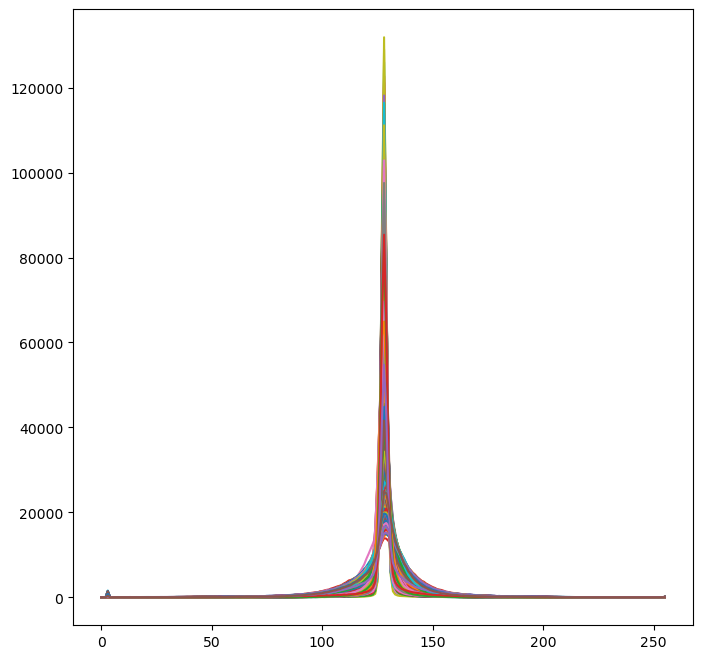

In [27]:
img_paths = Path(TRAIN_PATH).glob("*")
bar = tqdm(img_paths, total=df_train.id.unique().shape[0])     # should not be: total=len(list(img_paths))

plt.figure(figsize=(8,8))
for img_path in bar:
    img_bgr = cv2.imread(img_path.as_posix())    # BGR mode
    img_rgb = img_bgr[:, :, ::-1]                # RGB mode
    
    hist = cv2.calcHist([img_rgb], [0], None ,[256], [0,256])
    _ = plt.plot(hist)
plt.show()


## Display Some Images and Masks

### shsy5y

<Figure size 1600x800 with 0 Axes>

Text(0.5, 1.0, 'Shsy5y Original Image (BGR mode)')

Text(0.5, 1.0, 'Shsy5y Mask')

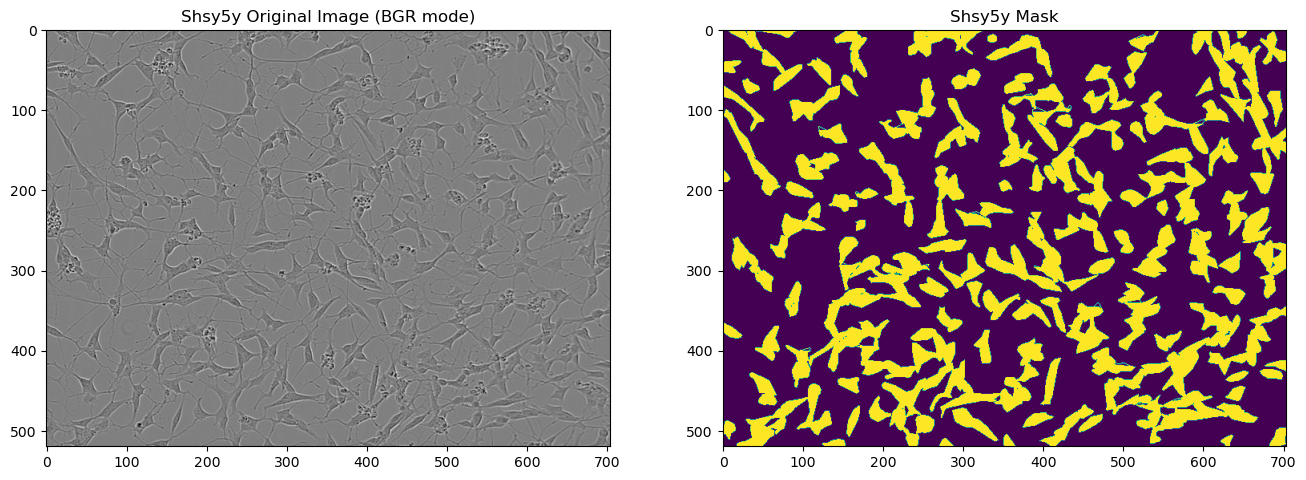

In [28]:
plt.figure(figsize=(16, 8))
img_id = "0030fd0e6378"
img = cv2.imread(TRAIN_PATH + img_id + ".png")         # BGR mode
ax1 = plt.subplot(121)
ax1.imshow(img)
ax1.set_title("Shsy5y Original Image (BGR mode)")

mask = build_image_mask(img, df_train[df_train.id == img_id].annotation.tolist())
ax2 = plt.subplot(122)
ax2.imshow(mask)
ax2.set_title("Shsy5y Mask")

plt.show()


<Figure size 1600x800 with 0 Axes>

Text(0.5, 1.0, 'Shsy5y Original Image (BGR mode) and Mask')

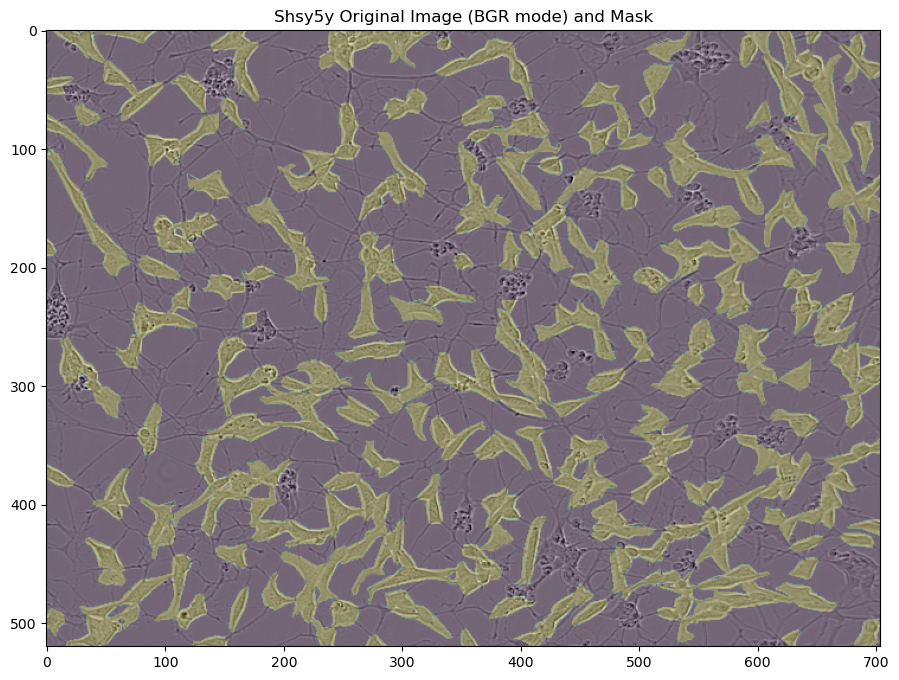

In [29]:
plt.figure(figsize=(16, 8))
img_id = "0030fd0e6378"
img = cv2.imread(TRAIN_PATH + img_id + ".png")          # BGR mode
plt.imshow(img)
plt.title("Shsy5y Original Image (BGR mode) and Mask")

mask = build_image_mask(img, df_train[df_train.id == img_id].annotation.tolist())
plt.imshow(mask, alpha=0.2)

plt.show()


### astro

<Figure size 1600x800 with 0 Axes>

Text(0.5, 1.0, 'Astro Original Image (BGR mode)')

Text(0.5, 1.0, 'Astro Mask')

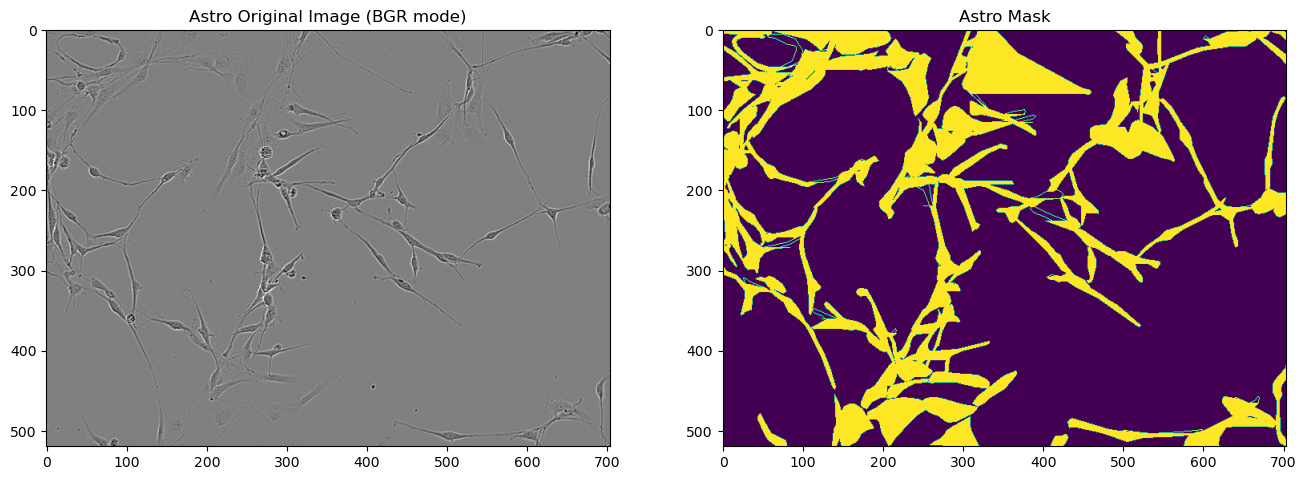

In [30]:
plt.figure(figsize=(16, 8))
img_id = "0140b3c8f445"
img = cv2.imread(TRAIN_PATH + img_id + ".png")         # BGR mode
ax1 = plt.subplot(121)
ax1.imshow(img)
ax1.set_title("Astro Original Image (BGR mode)")

mask = build_image_mask(img, df_train[df_train.id == img_id].annotation.tolist())
ax2 = plt.subplot(122)
ax2.imshow(mask)
ax2.set_title("Astro Mask")

plt.show()


<Figure size 1600x800 with 0 Axes>

Text(0.5, 1.0, 'Astro Original Image (BGR mode) and Mask')

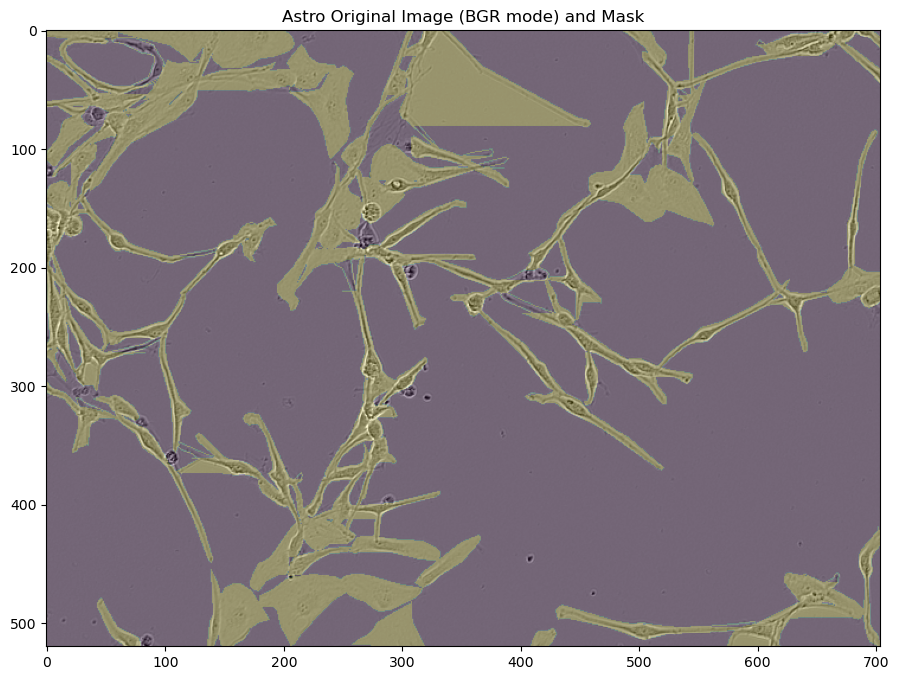

In [31]:
plt.figure(figsize=(16, 8))
img_id = "0140b3c8f445"
img = cv2.imread(TRAIN_PATH + img_id + ".png")          # BGR mode
plt.imshow(img)
plt.title("Astro Original Image (BGR mode) and Mask")

mask = build_image_mask(img, df_train[df_train.id == img_id].annotation.tolist())
plt.imshow(mask, alpha=0.2)

plt.show()


### cort

<Figure size 1600x800 with 0 Axes>

Text(0.5, 1.0, 'Cort Original Image (BGR mode)')

Text(0.5, 1.0, 'Cort Mask')

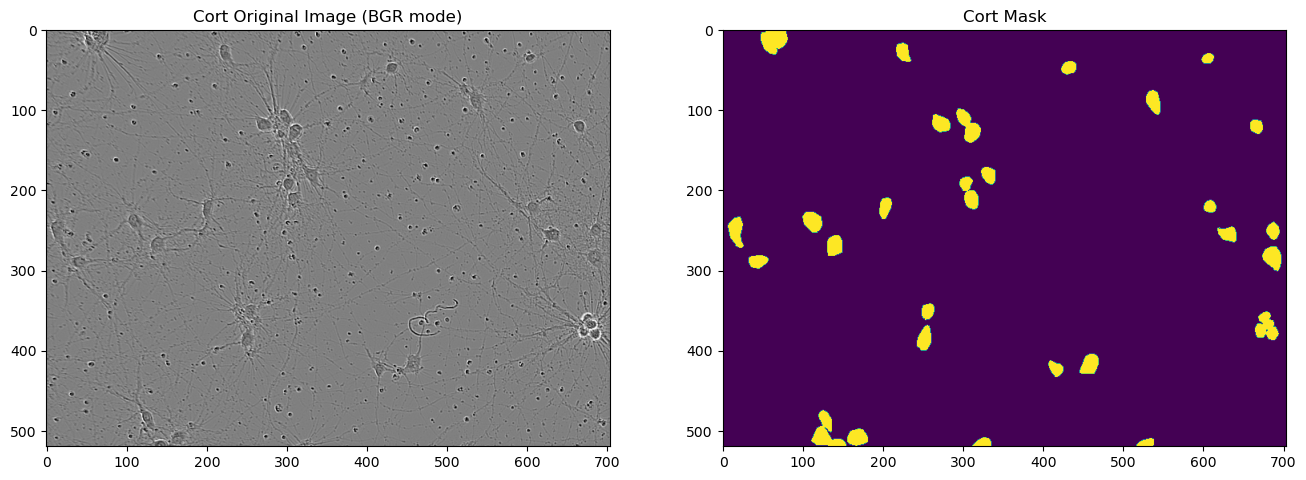

In [32]:
plt.figure(figsize=(16, 8))
img_id = "01ae5a43a2ab"
img = cv2.imread(TRAIN_PATH + img_id + ".png")         # BGR mode
ax1 = plt.subplot(121)
ax1.imshow(img)
ax1.set_title("Cort Original Image (BGR mode)")

mask = build_image_mask(img, df_train[df_train.id == img_id].annotation.tolist())
ax2 = plt.subplot(122)
ax2.imshow(mask)
ax2.set_title("Cort Mask")

plt.show()


<Figure size 1600x800 with 0 Axes>

Text(0.5, 1.0, 'Cort Original Image (BGR mode) and Mask')

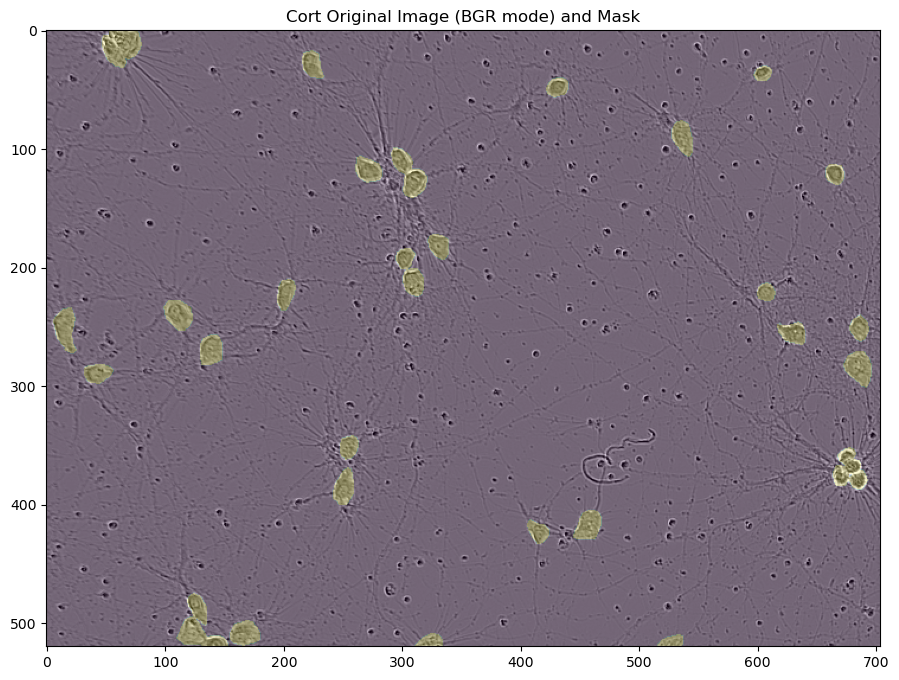

In [33]:
plt.figure(figsize=(16, 8))
img_id = "01ae5a43a2ab"
img = cv2.imread(TRAIN_PATH + img_id + ".png")          # BGR mode
plt.imshow(img)
plt.title("Cort Original Image (BGR mode) and Mask")

mask = build_image_mask(img, df_train[df_train.id == img_id].annotation.tolist())
plt.imshow(mask, alpha=0.2)

plt.show()


# Dataset and DataLoader

## Define CellDataset()

In [34]:
class CellDataset(Dataset):
    def __init__(self, df, train_path, transforms=None):
        super().__init__()
        self.df = df                    # df_train
        self.train_path = train_path
        self.transforms = transforms
        self.img_info = collections.defaultdict(dict)
        
        ## Encoding cell_type by dict
        ## result: {'shsy5y': 1, 'astro': 2, 'cort': 3}
        cell_type_dict = dict.fromkeys(df_train.cell_type.unique())  # {'shsy5y': None, 'astro': None, 'cort': None}
        v = 0
        for k in cell_type_dict.keys():
            v += 1
            cell_type_dict[k] = v
        
        ## 同一个 id 的所有 annotation 汇总成一个 list，并保留对应的 cell type 信息。
        df_info = df.groupby("id").agg({"annotation": lambda x: list(x),
                                        "cell_type": "first"}) \
                                  .reset_index()
        for idx, row in df_info.iterrows():
            self.img_info[idx] = {'image_id': row['id'],
                                  'image_path': os.path.join(self.train_path, row['id'] + '.png'),
                                  'annotations': row["annotation"],
                                  'cell_type' : cell_type_dict[row['cell_type']]}
    
    
    
    def get_box(self, instance_mask):
        """Get the bounding box of a given mask of an instance in an image"""
        pos = np.where(instance_mask)
        xmin = np.min(pos[1])
        xmax = np.max(pos[1])
        ymin = np.min(pos[0])
        ymax = np.max(pos[0])
        
        return [xmin, ymin, xmax, ymax]
    
    
    
    def __getitem__(self, idx):
        """Get the image and target"""        
        info = self.img_info[idx]
        img_path = info["image_path"]
        img = Image.open(img_path).convert("RGB")    # L mode -> RGB mode, also: 1 channel -> 3 channels
        n_instances = len(info["annotations"])
        
        masks = np.zeros((n_instances, HEIGHT, WIDTH), dtype=np.uint8)
        boxes = []        
        for i, annotation in enumerate(info["annotations"]):
            msk = rle_decode(annotation, (HEIGHT, WIDTH))            
            # msk = Image.fromarray(msk)
            # if self.should_resize:
            #     msk = msk.resize((self.width, self.height), resample=Image.BILINEAR)
            # msk = np.array(msk) > 0            
            masks[i, :, :] = msk
            boxes.append(self.get_box(msk))
        
        # dummy labels
        labels = [info["cell_type"] for _ in range(n_instances)]
        
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])    # area of each box
        labels = torch.as_tensor(labels, dtype=torch.int64)
        masks = torch.as_tensor(masks, dtype=torch.int8)
        image_id = torch.tensor([idx])
        iscrowd = torch.zeros((n_instances,), dtype=torch.int64)
        
        # The required target for the Mask R-CNN
        target = {"boxes": boxes,
                  'labels': labels,
                  'masks': masks,
                  'image_id': image_id,
                  'area': area,
                  'iscrowd': iscrowd}
        
        if self.transforms is not None:
            img, target = self.transforms(img, target)
        
        return img, target
    
    
    
    def __len__(self):
        return len(self.img_info)


## Define DataLoader

In [35]:
dataset_train = CellDataset(df=df_train, train_path=TRAIN_PATH, transforms=transforms(train=True))

dataloder_train = DataLoader(dataset_train, 
                             batch_size=BATCH_SIZE, 
                             shuffle=BATCH_SHUFFLE, 
                             # num_workers=2, 
                             collate_fn=lambda x: tuple(zip(*x))
                             )


# Model and Training

## Define Model

In [36]:
model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=True, 
                                                           box_detections_per_img=BOX_DETECTIONS_PER_IMG,
                                                           image_mean=RESNET_MEAN, 
                                                           image_std=RESNET_STD)    # model with normalization

# Get the number of input features for FastRCNNPredictor, that is
# the classification + bounding box regression layers for Faster R-CNN 
in_features = model.roi_heads.box_predictor.cls_score.in_features
# Replace the pre-trained head with a new one that is consistent with our CLASSES_NUM
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, CLASSES_NUM)


# Get the number of input features for the mask classifier
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
# Replace the mask predictor with a new one
model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, H_LAYER, CLASSES_NUM)


In [37]:
n_batches = len(dataloder_train)

loss_mask_list = np.zeros((EPOCHS, n_batches,))
loss_total_list = np.zeros((EPOCHS, n_batches,))

model.to(DEVICE) 
model.train();     # 句尾添加分号 ; 会抑制输出


======================================== Starting epoch 1 of 18 ========================================
[Batch  25 /  76] Batch total loss:   2.174. Batch mask loss:   0.439
[Batch  50 /  76] Batch total loss:   1.864. Batch mask loss:   0.359
[Batch  75 /  76] Batch total loss:   1.921. Batch mask loss:   0.337
[Batch  76 /  76] Batch total loss:   2.073. Batch mask loss:   0.405

[Epoch  1 / 18] Epoch average mask loss :   0.465
[Epoch  1 / 18] Epoch average total loss:   2.262.
[Epoch  1 / 18] time elapsed: [169 secs]


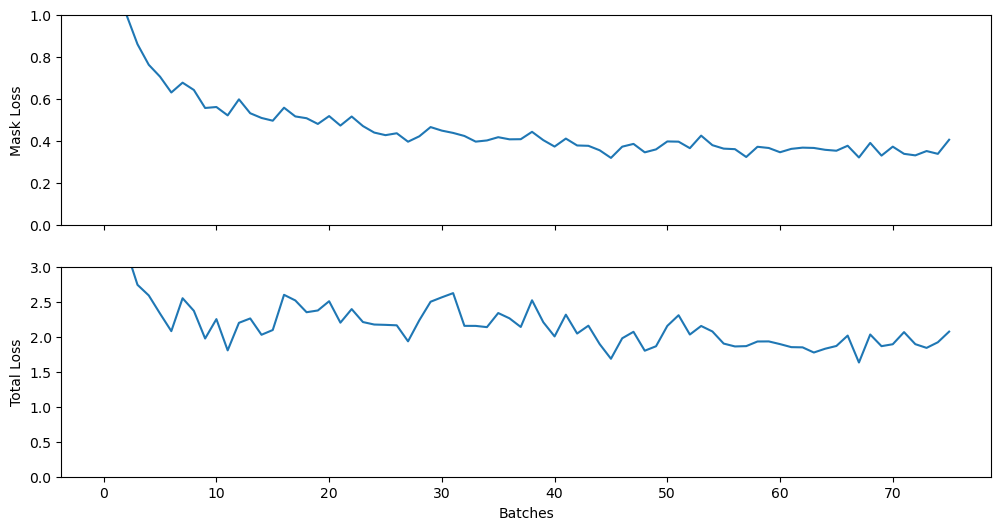

======================================== Starting epoch 2 of 18 ========================================
[Batch  25 /  76] Batch total loss:   1.805. Batch mask loss:   0.335
[Batch  50 /  76] Batch total loss:   1.870. Batch mask loss:   0.326
[Batch  75 /  76] Batch total loss:   1.627. Batch mask loss:   0.326
[Batch  76 /  76] Batch total loss:   1.510. Batch mask loss:   0.322

[Epoch  2 / 18] Epoch average mask loss :   0.336
[Epoch  2 / 18] Epoch average total loss:   1.708.
[Epoch  2 / 18] time elapsed: [169 secs]


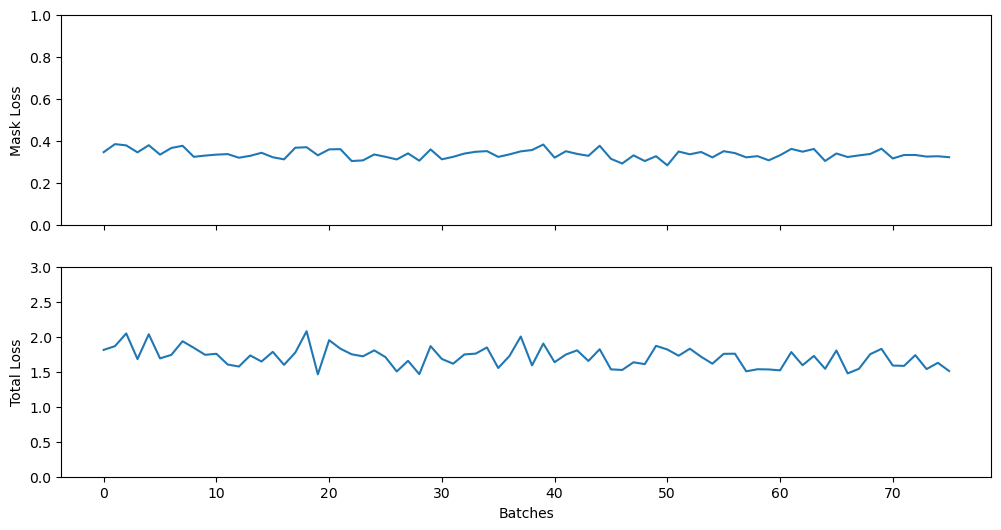

======================================== Starting epoch 3 of 18 ========================================
[Batch  25 /  76] Batch total loss:   1.722. Batch mask loss:   0.345
[Batch  50 /  76] Batch total loss:   1.695. Batch mask loss:   0.333
[Batch  75 /  76] Batch total loss:   1.507. Batch mask loss:   0.315
[Batch  76 /  76] Batch total loss:   1.463. Batch mask loss:   0.325

[Epoch  3 / 18] Epoch average mask loss :   0.323
[Epoch  3 / 18] Epoch average total loss:   1.578.
[Epoch  3 / 18] time elapsed: [168 secs]


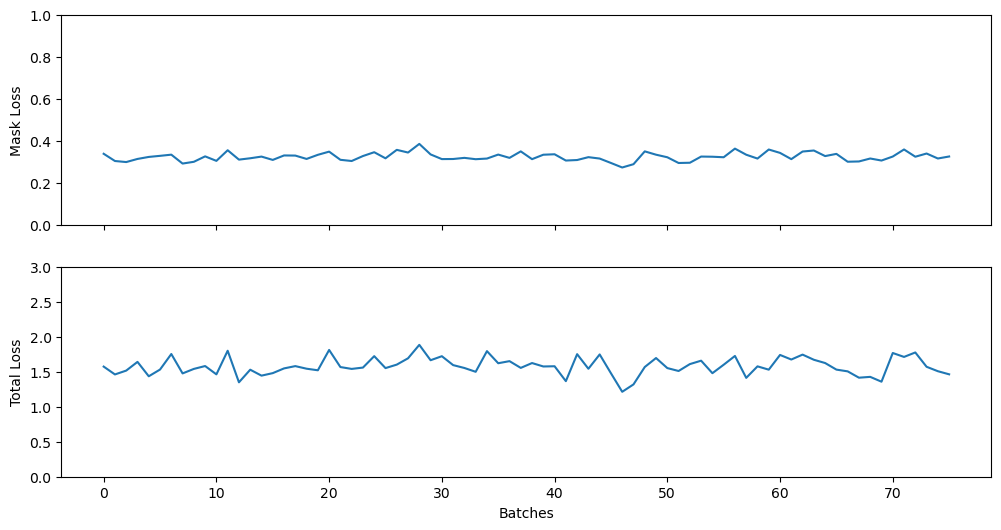

======================================== Starting epoch 4 of 18 ========================================
[Batch  25 /  76] Batch total loss:   1.698. Batch mask loss:   0.338
[Batch  50 /  76] Batch total loss:   1.789. Batch mask loss:   0.343
[Batch  75 /  76] Batch total loss:   1.462. Batch mask loss:   0.305
[Batch  76 /  76] Batch total loss:   1.730. Batch mask loss:   0.358

[Epoch  4 / 18] Epoch average mask loss :   0.320
[Epoch  4 / 18] Epoch average total loss:   1.524.
[Epoch  4 / 18] time elapsed: [169 secs]


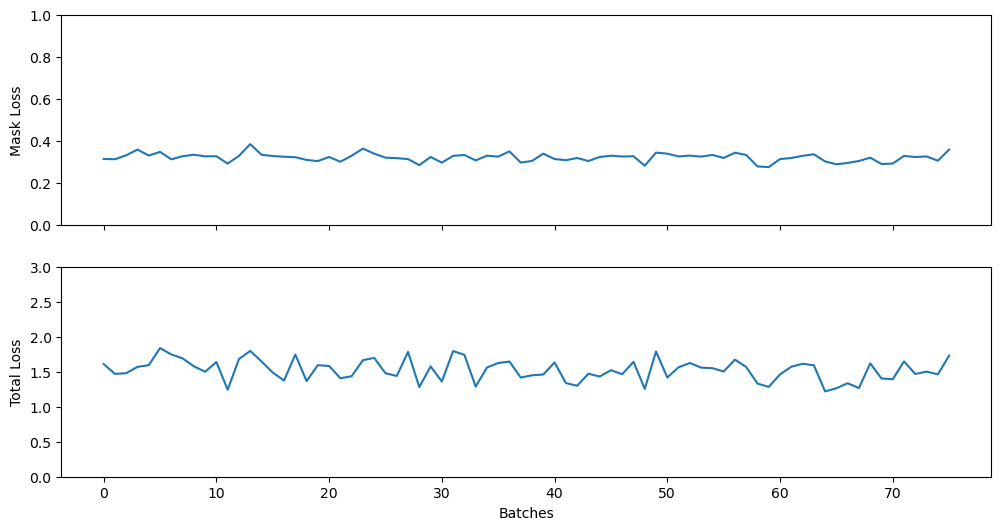

======================================== Starting epoch 5 of 18 ========================================
[Batch  25 /  76] Batch total loss:   1.434. Batch mask loss:   0.335
[Batch  50 /  76] Batch total loss:   1.396. Batch mask loss:   0.328
[Batch  75 /  76] Batch total loss:   1.594. Batch mask loss:   0.349
[Batch  76 /  76] Batch total loss:   1.381. Batch mask loss:   0.311

[Epoch  5 / 18] Epoch average mask loss :   0.317
[Epoch  5 / 18] Epoch average total loss:   1.488.
[Epoch  5 / 18] time elapsed: [169 secs]


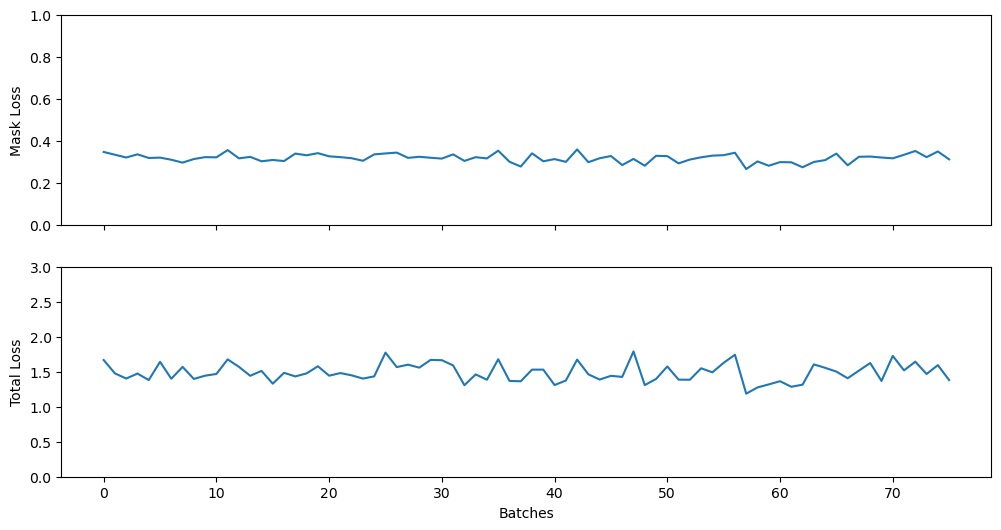

======================================== Starting epoch 6 of 18 ========================================
[Batch  25 /  76] Batch total loss:   1.481. Batch mask loss:   0.305
[Batch  50 /  76] Batch total loss:   1.362. Batch mask loss:   0.332
[Batch  75 /  76] Batch total loss:   1.419. Batch mask loss:   0.331
[Batch  76 /  76] Batch total loss:   1.432. Batch mask loss:   0.297

[Epoch  6 / 18] Epoch average mask loss :   0.317
[Epoch  6 / 18] Epoch average total loss:   1.469.
[Epoch  6 / 18] time elapsed: [169 secs]


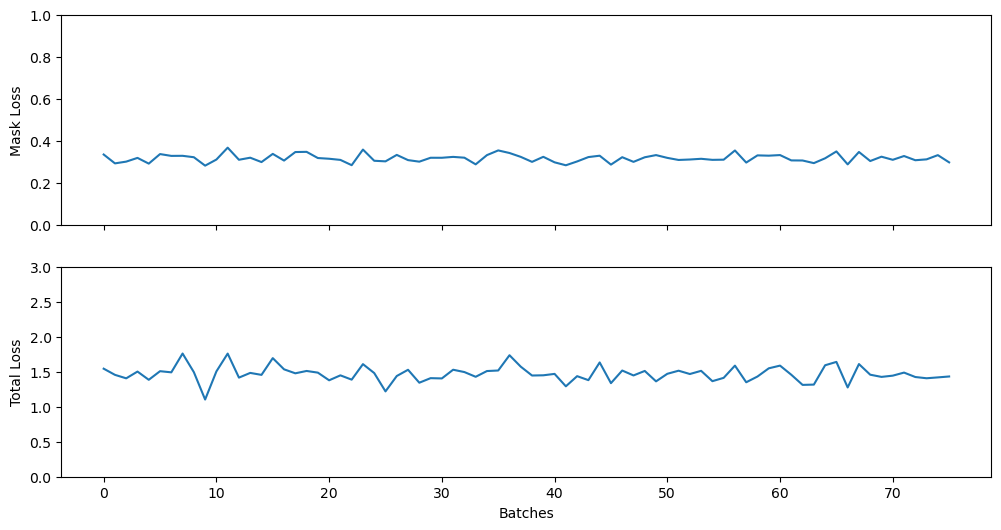

======================================== Starting epoch 7 of 18 ========================================
[Batch  25 /  76] Batch total loss:   1.387. Batch mask loss:   0.298
[Batch  50 /  76] Batch total loss:   1.355. Batch mask loss:   0.291
[Batch  75 /  76] Batch total loss:   1.453. Batch mask loss:   0.340
[Batch  76 /  76] Batch total loss:   1.417. Batch mask loss:   0.315

[Epoch  7 / 18] Epoch average mask loss :   0.314
[Epoch  7 / 18] Epoch average total loss:   1.446.
[Epoch  7 / 18] time elapsed: [169 secs]


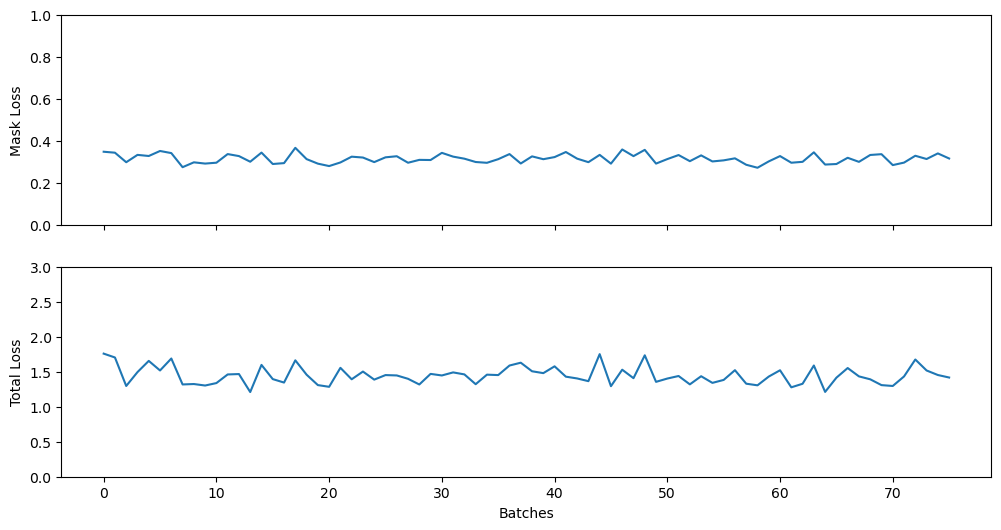

======================================== Starting epoch 8 of 18 ========================================
[Batch  25 /  76] Batch total loss:   1.166. Batch mask loss:   0.283
[Batch  50 /  76] Batch total loss:   1.322. Batch mask loss:   0.299
[Batch  75 /  76] Batch total loss:   1.591. Batch mask loss:   0.341
[Batch  76 /  76] Batch total loss:   1.420. Batch mask loss:   0.309

[Epoch  8 / 18] Epoch average mask loss :   0.313
[Epoch  8 / 18] Epoch average total loss:   1.439.
[Epoch  8 / 18] time elapsed: [169 secs]


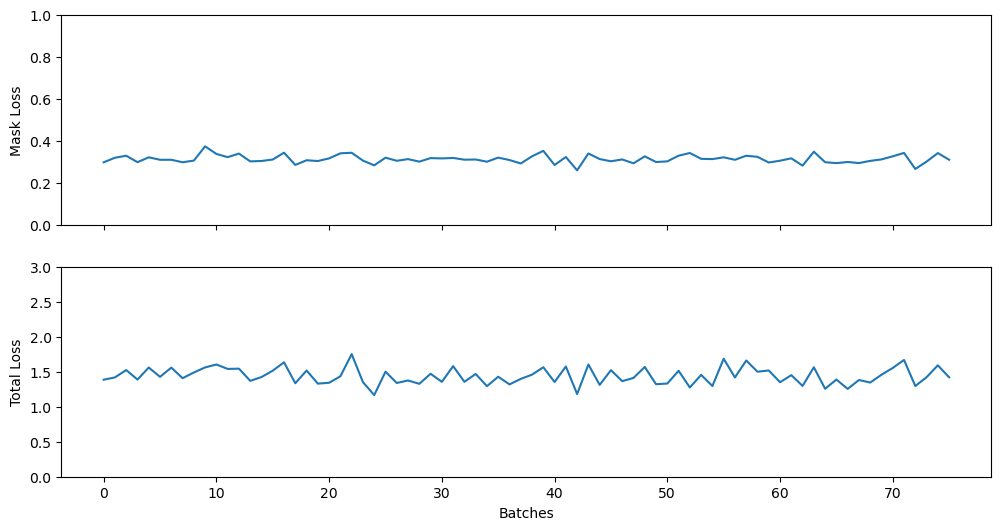

======================================== Starting epoch 9 of 18 ========================================
[Batch  25 /  76] Batch total loss:   1.643. Batch mask loss:   0.322
[Batch  50 /  76] Batch total loss:   1.415. Batch mask loss:   0.301
[Batch  75 /  76] Batch total loss:   1.205. Batch mask loss:   0.277
[Batch  76 /  76] Batch total loss:   1.615. Batch mask loss:   0.334

[Epoch  9 / 18] Epoch average mask loss :   0.312
[Epoch  9 / 18] Epoch average total loss:   1.417.
[Epoch  9 / 18] time elapsed: [170 secs]


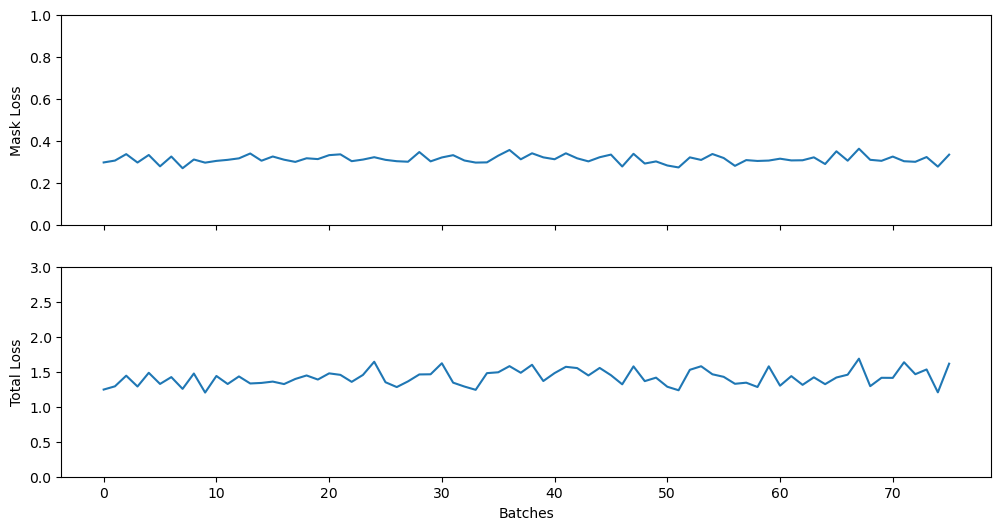

======================================== Starting epoch 10 of 18 ========================================
[Batch  25 /  76] Batch total loss:   1.308. Batch mask loss:   0.299
[Batch  50 /  76] Batch total loss:   1.479. Batch mask loss:   0.316
[Batch  75 /  76] Batch total loss:   1.394. Batch mask loss:   0.328
[Batch  76 /  76] Batch total loss:   1.336. Batch mask loss:   0.338

[Epoch 10 / 18] Epoch average mask loss :   0.310
[Epoch 10 / 18] Epoch average total loss:   1.422.
[Epoch 10 / 18] time elapsed: [169 secs]


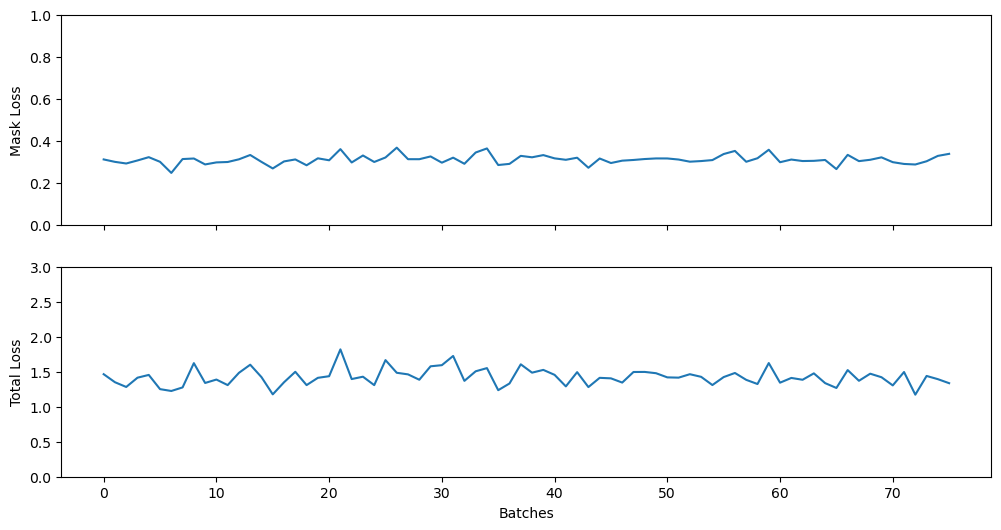

======================================== Starting epoch 11 of 18 ========================================
[Batch  25 /  76] Batch total loss:   1.498. Batch mask loss:   0.328
[Batch  50 /  76] Batch total loss:   1.302. Batch mask loss:   0.298
[Batch  75 /  76] Batch total loss:   1.169. Batch mask loss:   0.292
[Batch  76 /  76] Batch total loss:   1.341. Batch mask loss:   0.308

[Epoch 11 / 18] Epoch average mask loss :   0.311
[Epoch 11 / 18] Epoch average total loss:   1.396.
[Epoch 11 / 18] time elapsed: [169 secs]


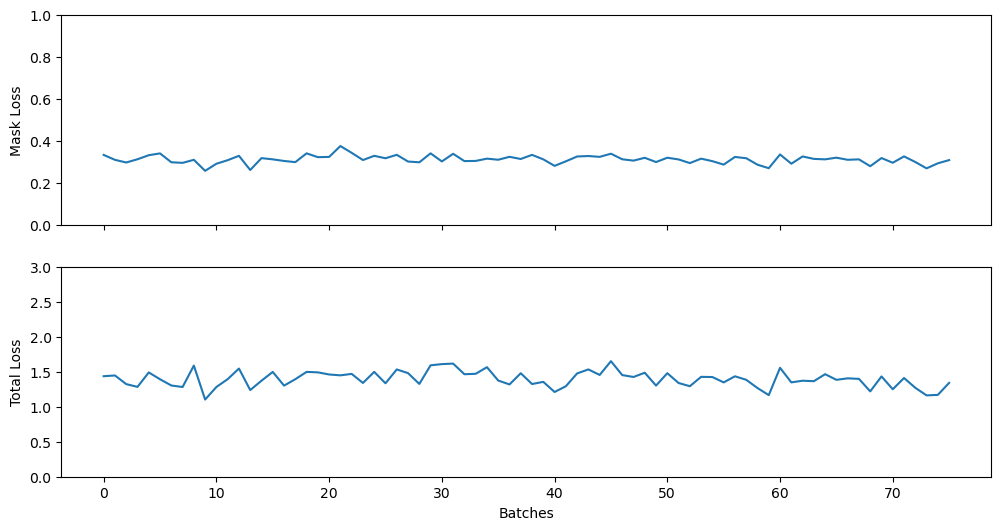

======================================== Starting epoch 12 of 18 ========================================
[Batch  25 /  76] Batch total loss:   1.370. Batch mask loss:   0.313
[Batch  50 /  76] Batch total loss:   1.258. Batch mask loss:   0.297
[Batch  75 /  76] Batch total loss:   1.309. Batch mask loss:   0.311
[Batch  76 /  76] Batch total loss:   1.434. Batch mask loss:   0.315

[Epoch 12 / 18] Epoch average mask loss :   0.309
[Epoch 12 / 18] Epoch average total loss:   1.400.
[Epoch 12 / 18] time elapsed: [169 secs]


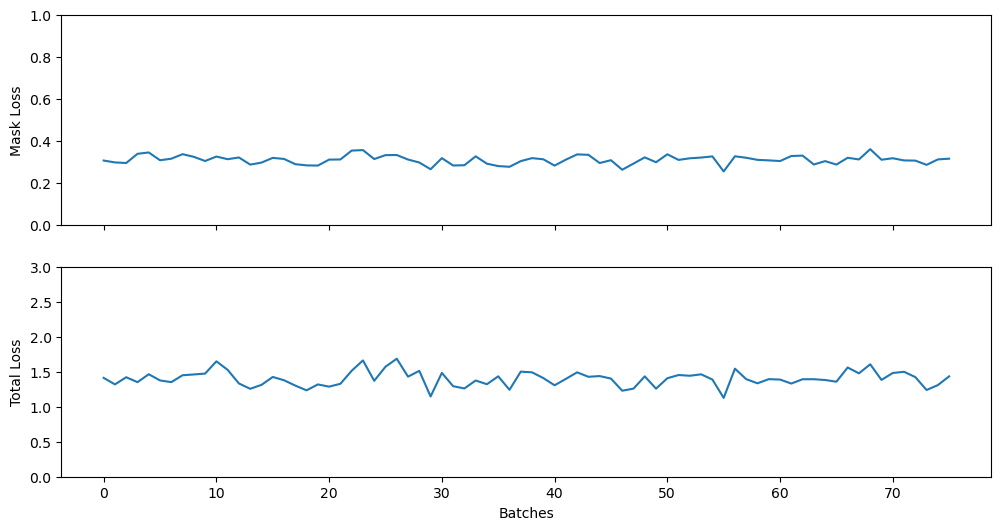

======================================== Starting epoch 13 of 18 ========================================
[Batch  25 /  76] Batch total loss:   1.573. Batch mask loss:   0.312
[Batch  50 /  76] Batch total loss:   1.415. Batch mask loss:   0.306
[Batch  75 /  76] Batch total loss:   1.610. Batch mask loss:   0.328
[Batch  76 /  76] Batch total loss:   1.435. Batch mask loss:   0.316

[Epoch 13 / 18] Epoch average mask loss :   0.309
[Epoch 13 / 18] Epoch average total loss:   1.405.
[Epoch 13 / 18] time elapsed: [169 secs]


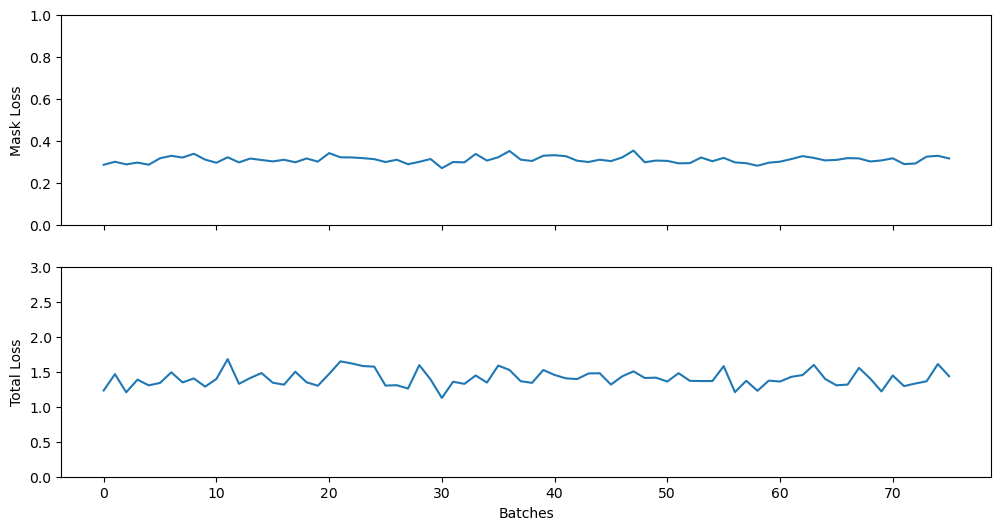

======================================== Starting epoch 14 of 18 ========================================
[Batch  25 /  76] Batch total loss:   1.354. Batch mask loss:   0.313
[Batch  50 /  76] Batch total loss:   1.294. Batch mask loss:   0.289
[Batch  75 /  76] Batch total loss:   1.358. Batch mask loss:   0.307
[Batch  76 /  76] Batch total loss:   1.387. Batch mask loss:   0.311

[Epoch 14 / 18] Epoch average mask loss :   0.307
[Epoch 14 / 18] Epoch average total loss:   1.381.
[Epoch 14 / 18] time elapsed: [170 secs]


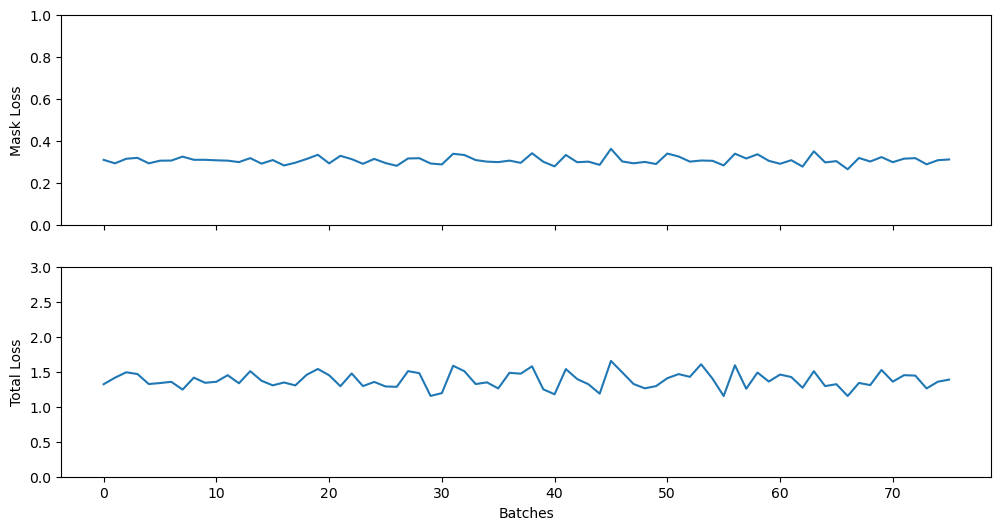

======================================== Starting epoch 15 of 18 ========================================
[Batch  25 /  76] Batch total loss:   1.475. Batch mask loss:   0.306
[Batch  50 /  76] Batch total loss:   1.346. Batch mask loss:   0.293
[Batch  75 /  76] Batch total loss:   1.449. Batch mask loss:   0.313
[Batch  76 /  76] Batch total loss:   1.390. Batch mask loss:   0.302

[Epoch 15 / 18] Epoch average mask loss :   0.307
[Epoch 15 / 18] Epoch average total loss:   1.373.
[Epoch 15 / 18] time elapsed: [169 secs]


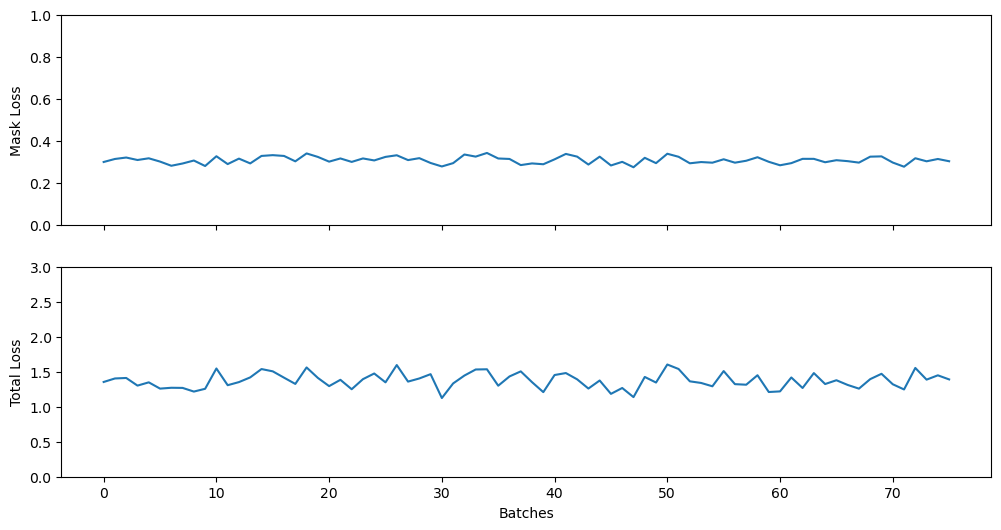

======================================== Starting epoch 16 of 18 ========================================
[Batch  25 /  76] Batch total loss:   1.209. Batch mask loss:   0.303
[Batch  50 /  76] Batch total loss:   1.302. Batch mask loss:   0.321
[Batch  75 /  76] Batch total loss:   1.225. Batch mask loss:   0.289
[Batch  76 /  76] Batch total loss:   1.482. Batch mask loss:   0.334

[Epoch 16 / 18] Epoch average mask loss :   0.308
[Epoch 16 / 18] Epoch average total loss:   1.371.
[Epoch 16 / 18] time elapsed: [170 secs]


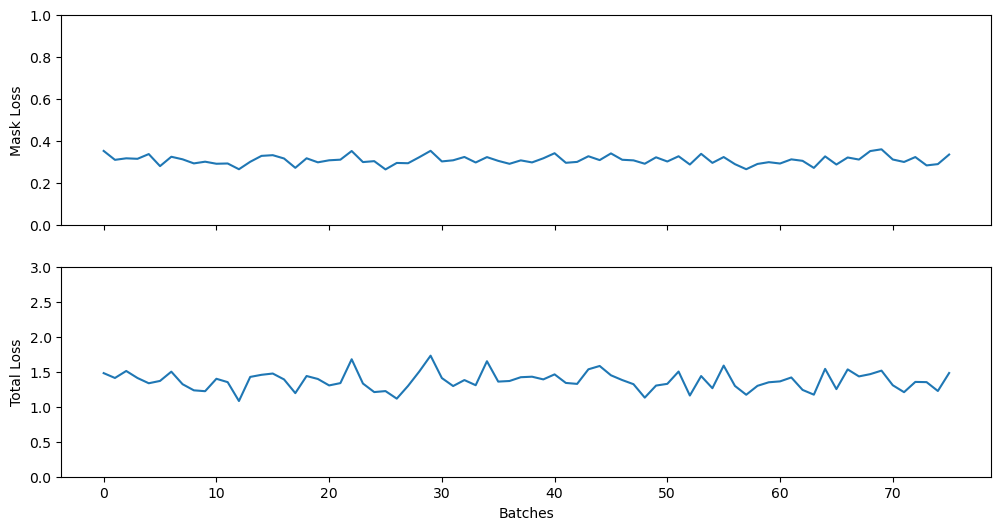

======================================== Starting epoch 17 of 18 ========================================
[Batch  25 /  76] Batch total loss:   1.282. Batch mask loss:   0.313
[Batch  50 /  76] Batch total loss:   1.264. Batch mask loss:   0.316
[Batch  75 /  76] Batch total loss:   1.376. Batch mask loss:   0.324
[Batch  76 /  76] Batch total loss:   1.333. Batch mask loss:   0.322

[Epoch 17 / 18] Epoch average mask loss :   0.307
[Epoch 17 / 18] Epoch average total loss:   1.361.
[Epoch 17 / 18] time elapsed: [170 secs]


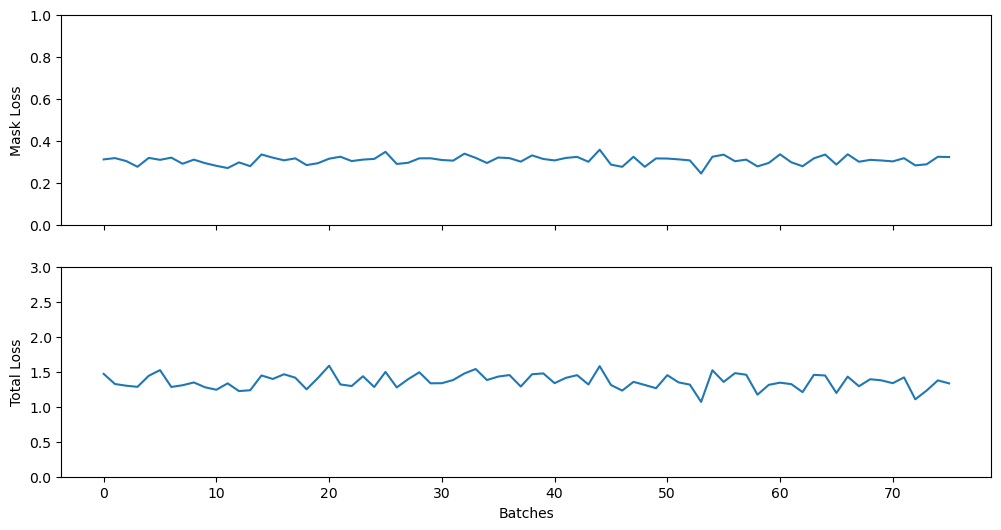

======================================== Starting epoch 18 of 18 ========================================
[Batch  25 /  76] Batch total loss:   1.460. Batch mask loss:   0.302
[Batch  50 /  76] Batch total loss:   1.390. Batch mask loss:   0.312
[Batch  75 /  76] Batch total loss:   1.190. Batch mask loss:   0.308
[Batch  76 /  76] Batch total loss:   1.408. Batch mask loss:   0.311

[Epoch 18 / 18] Epoch average mask loss :   0.306
[Epoch 18 / 18] Epoch average total loss:   1.361.
[Epoch 18 / 18] time elapsed: [169 secs]


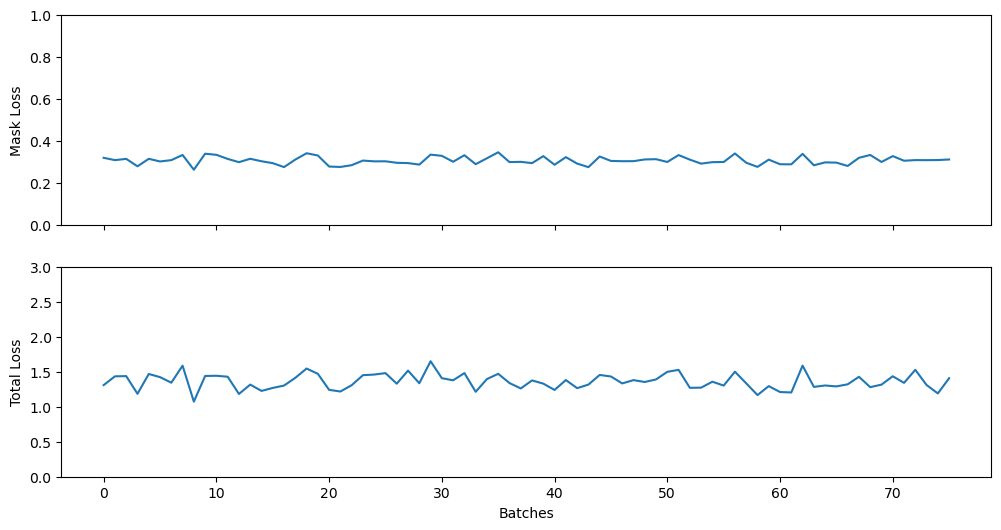

CPU times: user 1h 4min 21s, sys: 10min 35s, total: 1h 14min 56s
Wall time: 50min 47s


In [38]:
%%time

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=LEARNING_RATE, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)

lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

for epoch in range(1, EPOCHS + 1):
    print("="*40 + f" Starting epoch {epoch} of {EPOCHS} " + "="*40)
    
    time_start = time.time()
    loss_total_accum = 0.0
    loss_mask_accum = 0.0
    
    for batch_idx, (images, targets) in enumerate(dataloder_train, 1):
    
        # Predict
        images = list(image.to(DEVICE) for image in images)
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss_total = sum(loss for loss in loss_dict.values())
        
        # Backprop
        optimizer.zero_grad()
        loss_total.backward()
        optimizer.step()
        
        # Logging
        loss_total_accum += loss_total.item()
        loss_mask = loss_dict['loss_mask'].item()
        loss_mask_accum += loss_mask
        
        loss_mask_list[epoch - 1, batch_idx - 1] = loss_mask
        loss_total_list[epoch - 1, batch_idx - 1] = loss_total.item()
        
        if (batch_idx % 25 == 0) or (batch_idx == n_batches):
            print(f"[Batch {batch_idx:3d} / {n_batches:3d}] Batch total loss: {loss_total.item():7.3f}. Batch mask loss: {loss_mask:7.3f}")
    
    if USE_SCHEDULER:
        lr_scheduler.step()
    
    # Average training loss at this epoch
    loss_total_avg = loss_total_accum / n_batches
    loss_mask_avg = loss_mask_accum / n_batches
    
    # Time consuming of this training epoch
    elapsed = time.time() - time_start
    
    print()
    prefix = f"[Epoch {epoch:2d} / {EPOCHS:2d}]"
    print(f"{prefix} Epoch average mask loss : {loss_mask_avg:7.3f}")
    print(f"{prefix} Epoch average total loss: {loss_total_avg:7.3f}.")
    print(f"{prefix} time elapsed: [{elapsed:.0f} secs]")
    
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    ax1.set_ylim(0, 1)
    ax1.plot(loss_mask_list[epoch-1])
    ax1.set_ylabel("Mask Loss")
    
    ax2.set_ylim(0, 3)
    ax2.plot(loss_total_list[epoch-1])
    ax2.set_ylabel("Total Loss")
    ax2.set_xlabel("Batches")
    plt.show()


In [39]:
# saving the trained model 
torch.save(model.state_dict(), 'resnet50_mask-rcnn_model.pth') 


## Inference on train data


In [40]:
class CellTrainEvaluate(Dataset):
    def __init__(self, train_path, transforms=None):
        self.transforms = transforms
        self.image_dir = train_path
        self.image_ids = [file_name[:-4] for file_name in os.listdir(self.image_dir)]
        
    
    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image_path = os.path.join(self.image_dir, image_id + ".png")
        image = Image.open(image_path).convert("RGB")    
        
        if self.transforms is not None:
            image, _ = self.transforms(image=image, target=None)
        
        return {'image': image, 'image_id': image_id}
    
    
    def __len__(self):
        return len(self.image_ids)
    
dataset_train = CellTrainEvaluate(TRAIN_PATH, transforms=transforms(train=False))

def rle_encoding(x):
    dots = np.where(x.flatten() == 1)[0]
    run_lengths = []
    prev = -2
    for b in dots:
        if (b>prev+1): run_lengths.extend((b + 1, 0))
        run_lengths[-1] += 1
        prev = b
    
    return ' '.join(map(str, run_lengths))

def remove_overlapping_pixels(mask, other_masks):
    for other_mask in other_masks:
        if np.sum(np.logical_and(mask, other_mask)) > 0:
            mask[np.logical_and(mask, other_mask)] = 0
    
    return mask

model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=False,
                                                           box_detections_per_img=BOX_DETECTIONS_PER_IMG,
                                                           image_mean=RESNET_MEAN,
                                                           image_std=RESNET_STD)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, CLASSES_NUM)
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, H_LAYER, CLASSES_NUM)

# Load the pre-trained weights
state_dict = torch.load('resnet50_mask-rcnn_model.pth', map_location=torch.device(DEVICE))
model.load_state_dict(state_dict)

# Move the model to the GPU
model.to(DEVICE)

model.eval()  # Set the model to evaluation mode

submission = []
for sample in dataset_train:
    img = sample['image']
    image_id = sample['image_id']
    with torch.no_grad():
        result = model([img.to(DEVICE)])[0]
    
    previous_masks = []
    for i, mask in enumerate(result["masks"]):
        
        # Filter-out low-scoring results. Not tried yet.
        score = result["scores"][i].cpu().item()
        if score < MIN_SCORE:                   # MIN_SCORE = 0.59
            continue
        
        mask = mask.cpu().numpy()
        # Keep only highly likely pixels
        binary_mask = mask > MASK_THRESHOLD    # MASK_THRESHOLD = 0.5
        binary_mask = remove_overlapping_pixels(binary_mask, previous_masks)
        previous_masks.append(binary_mask)
        rle = rle_encoding(binary_mask)
        submission.append((image_id, rle))
    
    # Add empty prediction if no RLE was generated for this image
    all_images_ids = [image_id for image_id, rle in submission]
    if image_id not in all_images_ids:
        submission.append((image_id, ""))

pd.DataFrame(submission, columns=['id', 'predicted']).to_csv( root_address + "/val_predictions.csv", index=False)


<All keys matched successfully>

MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu):

MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu):

In [41]:
def rles_to_mask(encs, shape):
    """
    Decodes a rle.

    Args:
        encs (list of str): Rles for each class.
        shape (tuple [2]): Mask size.

    Returns:
        np array [shape]: Mask.
    """
    img = np.zeros(shape[0] * shape[1], dtype=np.uint)
    if type(encs)==float:
        return img
    for m, enc in enumerate(encs):
        if isinstance(enc, float) and np.isnan(enc):
            continue
        enc_split = enc.split()
        for i in range(len(enc_split) // 2):
            start = int(enc_split[2 * i]) - 1
            length = int(enc_split[2 * i + 1])
            img[start: start + length] = 1 + m
    return img.reshape(shape) 

def compute_iou(labels, y_pred):
    """
    Computes the IoU for instance labels and predictions.

    Args:
        labels (np array): Labels.
        y_pred (np array): predictions

    Returns:
        np array: IoU matrix, of size true_objects x pred_objects.
    """

    true_objects = len(np.unique(labels))
    pred_objects = len(np.unique(y_pred))

    # Compute intersection between all objects
    intersection = np.histogram2d(
        labels.flatten(), y_pred.flatten(), bins=(true_objects, pred_objects)
    )[0]

    # Compute areas (needed for finding the union between all objects)
    area_true = np.histogram(labels, bins=true_objects)[0]
    area_pred = np.histogram(y_pred, bins=pred_objects)[0]
    area_true = np.expand_dims(area_true, -1)
    area_pred = np.expand_dims(area_pred, 0)

    # Compute union
    union = area_true + area_pred - intersection
    iou = intersection / union
    
    return iou[1:, 1:]  # exclude background

def precision_at(threshold, iou):
    """
    Computes the precision at a given threshold.

    Args:
        threshold (float): Threshold.
        iou (np array [n_truths x n_preds]): IoU matrix.

    Returns:
        int: Number of true positives,
        int: Number of false positives,
        int: Number of false negatives.
    """
    matches = iou > threshold
    true_positives = np.sum(matches, axis=1) >= 1  # Correct objects
    false_negatives = np.sum(matches, axis=1) == 0  # Missed objects
    false_positives = np.sum(matches, axis=0) == 0  # Extra objects
    tp, fp, fn = (
        np.sum(true_positives),
        np.sum(false_positives),
        np.sum(false_negatives),
    )
    return tp, fp, fn

from tqdm.auto import tqdm
def iou_map(truths, preds, verbose=0):
    """
    Computes the metric for the competition.
    Masks contain the segmented pixels where each object has one value associated,
    and 0 is the background.

    Args:
        truths (list of masks): Ground truths.
        preds (list of masks): Predictions.
        verbose (int, optional): Whether to print infos. Defaults to 0.

    Returns:
        float: mAP.
    """
    ious = [
        compute_iou(rles_to_mask(truth,shape), rles_to_mask(pred,shape)) 
            for truth, pred in tqdm(zip(truths, preds))
    ]
    
    if verbose:
        print(ious[0].shape)
        print("Thresh\tTP\tFP\tFN\tPrec.")

    prec = []
    for t in np.arange(0.5, 1.0, 0.05):
        tps, fps, fns = 0, 0, 0
        for iou in ious:
            tp, fp, fn = precision_at(t, iou)
            tps += tp
            fps += fp
            fns += fn

        p = tps / (tps + fps + fns)
        prec.append(p)

        if verbose:
            print("{:1.3f}\t{}\t{}\t{}\t{:1.3f}".format(t, tps, fps, fns, p))

    if verbose:
        print("AP\t-\t-\t-\t{:1.3f}".format(np.mean(prec)))

    return np.mean(prec)


In [42]:
width = 704
height = 520
shape = [height,width]

train_df = pd.read_csv('/home/nima/drive/test_code/data_analytics_HW3/sartorius-cell-instance-segmentation/train.csv')
train_df = train_df.groupby('id').annotation.agg(list).reset_index()

cellpose_predictions = pd.read_csv('val_predictions.csv')
cellpose_predictions = cellpose_predictions.groupby('id').predicted.agg(list).reset_index()
df = pd.merge(train_df,cellpose_predictions,on='id')

print(df.shape)

df.sample(5)


(606, 3)


,id,annotation,predicted
224,5a880b2b403e,[56062 1 56765 3 57469 4 58172 6 58875 8 59579...,[110843 6 111547 7 112251 7 112955 8 113659 8 ...
520,db8bc8f09776,[135424 3 136124 8 136828 8 137531 10 138235 1...,[325792 10 326496 13 327200 16 327905 17 32861...
143,3f14453053d4,[64031 1 64732 4 65433 7 66133 11 66824 24 675...,[324000 14 324704 16 325408 17 326112 17 32681...
401,a9cf3efd023a,[29841 5 30545 7 31249 8 31954 8 32658 8 33362...,[31260 4 31963 8 32666 10 33370 11 34073 14 34...
562,ebffbf1cfe00,[10480 4 11180 8 11882 10 12584 13 13286 15 13...,[267778 10 268481 12 269184 13 269887 14 27059...


### plotting some annotations and their predictions 


0030fd0e6378


Text(0.5, 1.0, 'ground truth')

(-0.5, 703.5, 519.5, -0.5)

Text(0.5, 1.0, 'prediction')

(-0.5, 703.5, 519.5, -0.5)

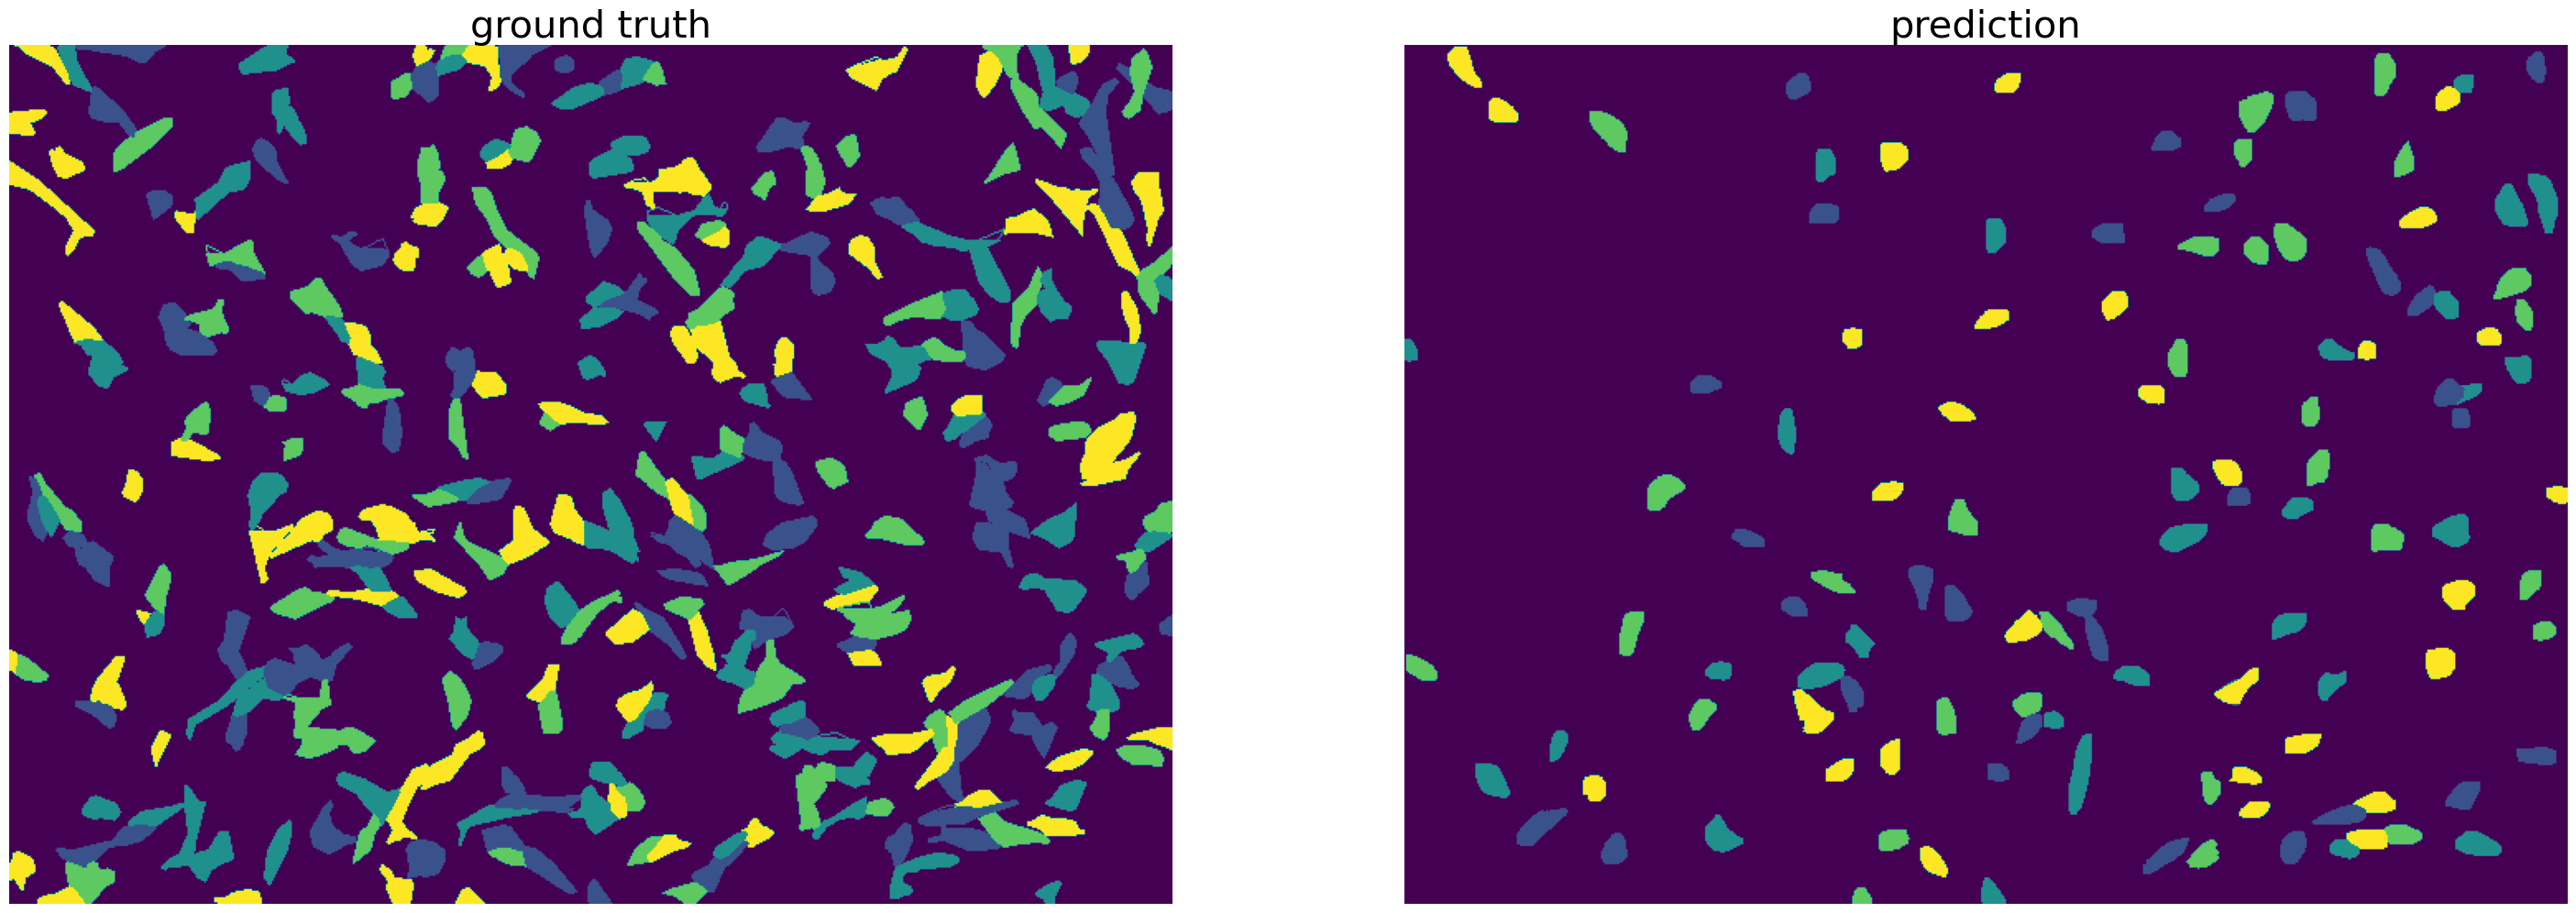

0140b3c8f445


Text(0.5, 1.0, 'ground truth')

(-0.5, 703.5, 519.5, -0.5)

Text(0.5, 1.0, 'prediction')

(-0.5, 703.5, 519.5, -0.5)

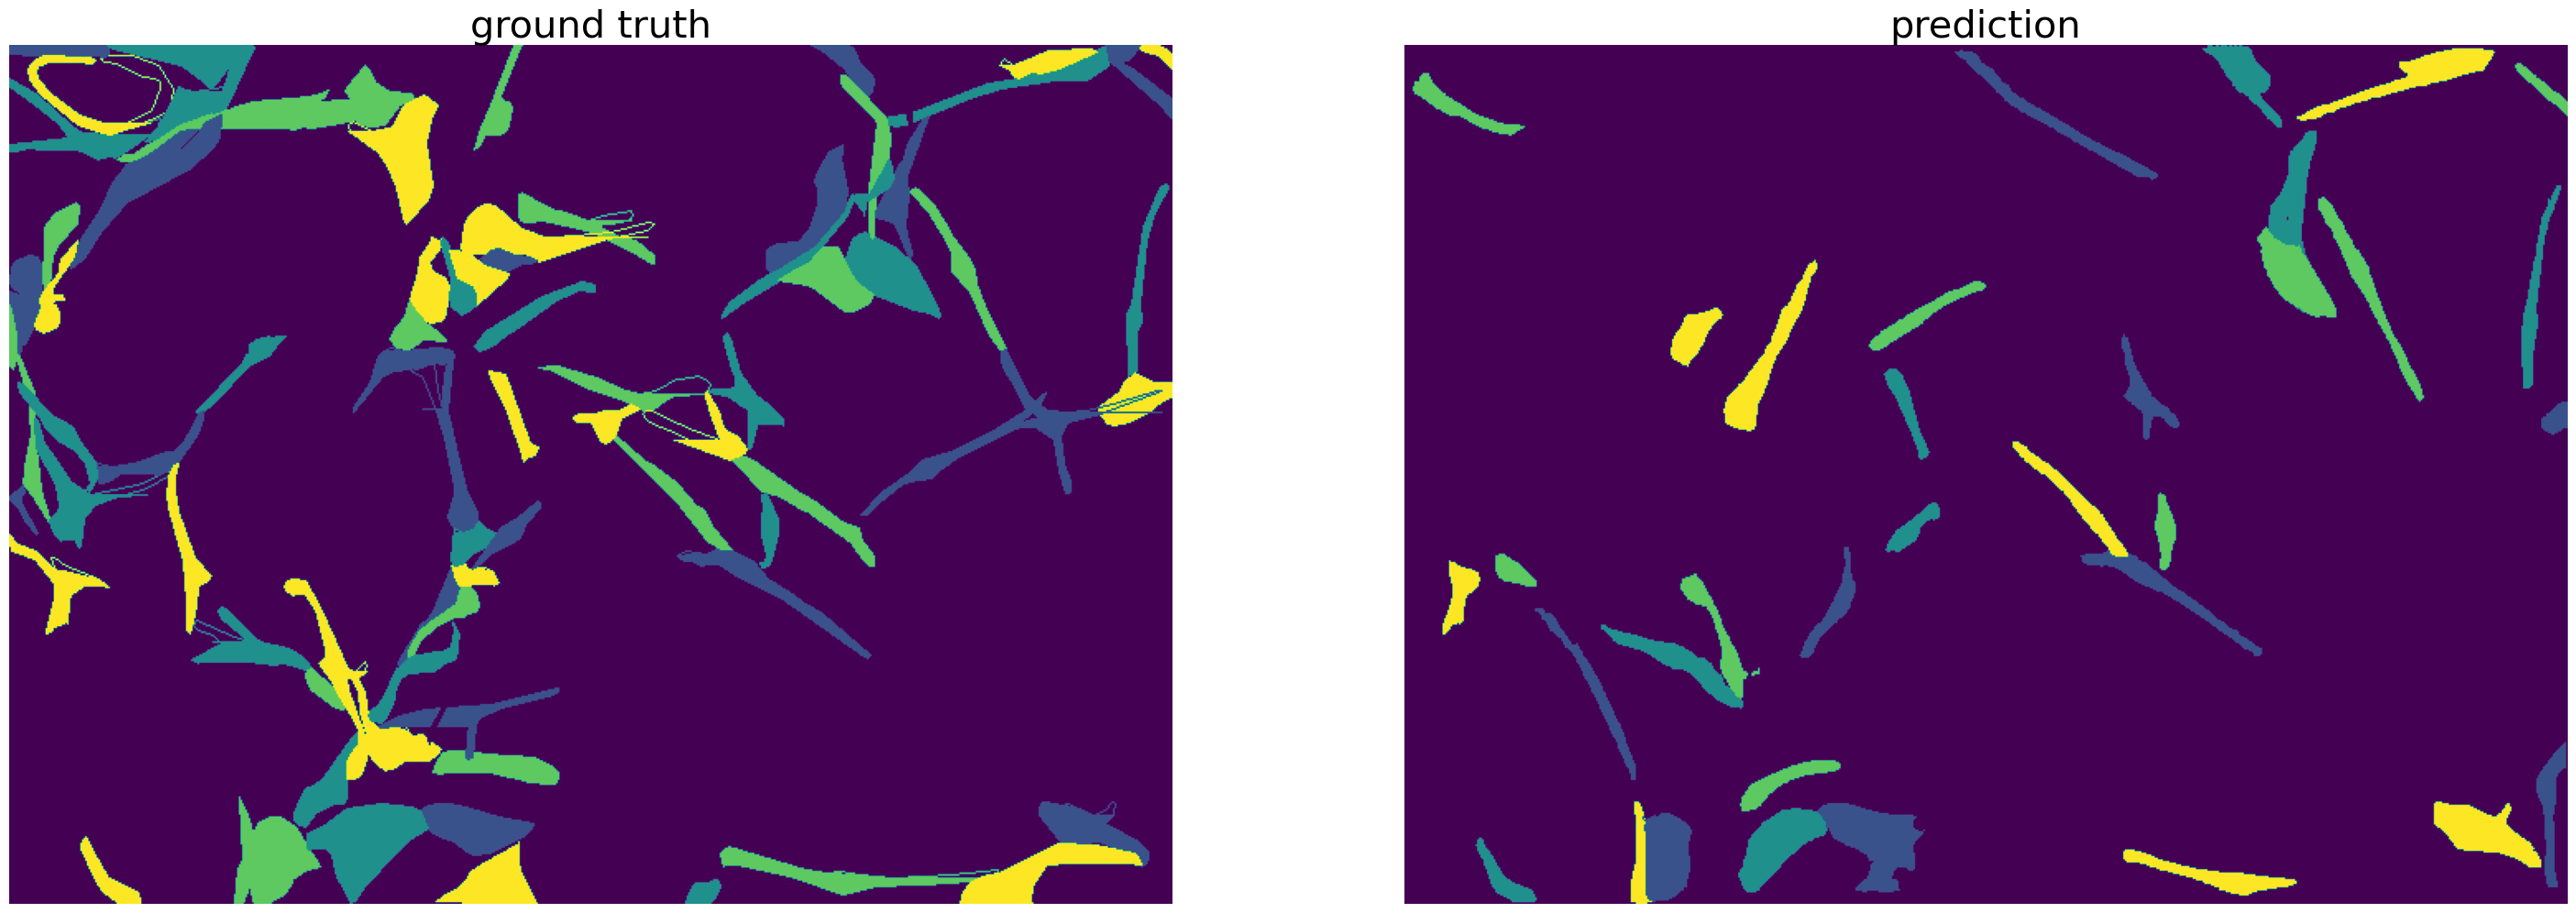

01ae5a43a2ab


Text(0.5, 1.0, 'ground truth')

(-0.5, 703.5, 519.5, -0.5)

Text(0.5, 1.0, 'prediction')

(-0.5, 703.5, 519.5, -0.5)

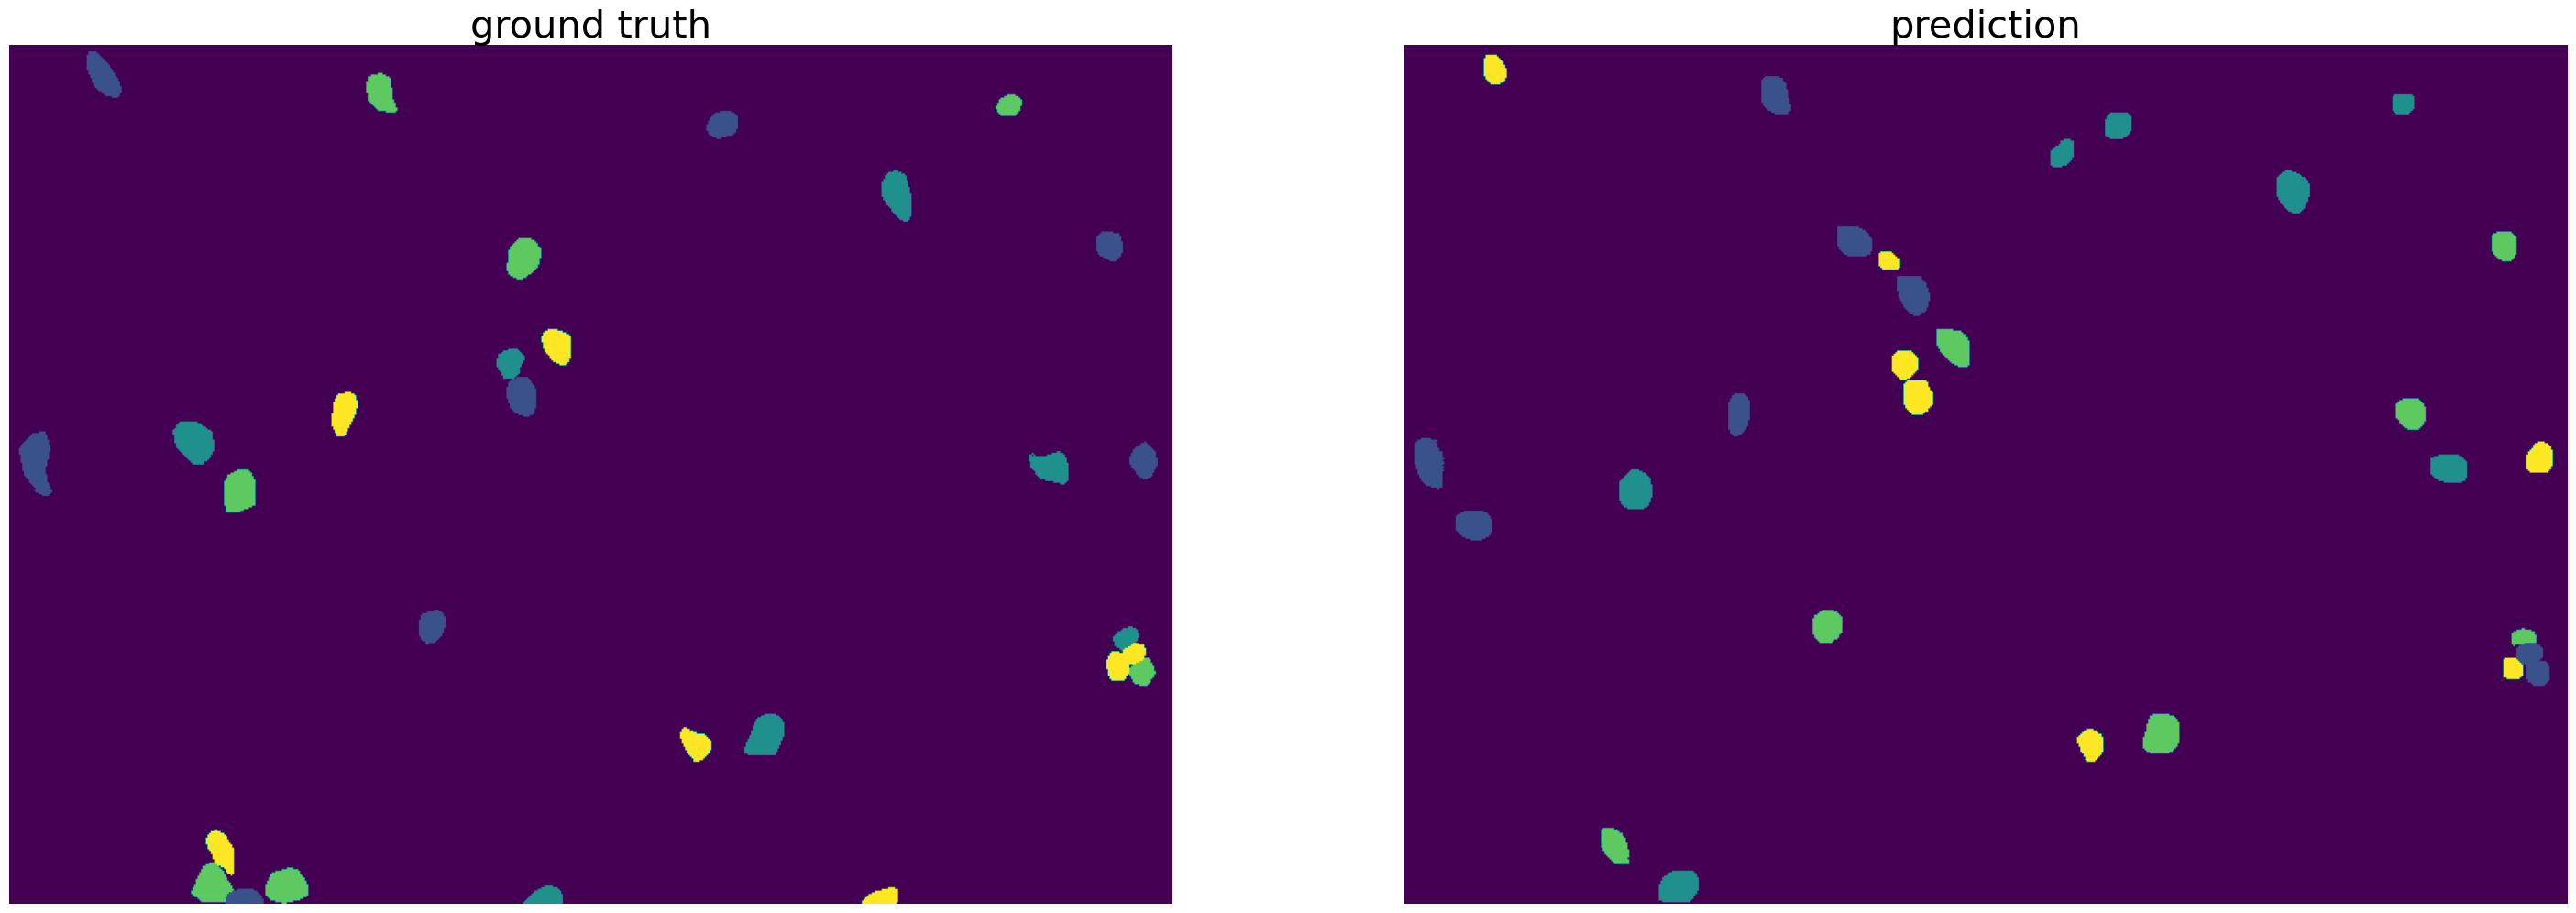

In [43]:
for i,row in df.iterrows():
    
    print(row.id)
    gt_masks = rles_to_mask(row.annotation, shape).astype(np.uint16)
    predicted_masks = rles_to_mask(row.predicted, shape).astype(np.uint16)
    
    gt_masks = (gt_masks>0).astype(int)*(gt_masks%5)
    predicted_masks = (predicted_masks>0).astype(int)*(predicted_masks%5)

    _, axs = plt.subplots(1, 2, figsize=(36, 18))
    axs = axs.flatten()
    axs[0].imshow(gt_masks)
    axs[0].set_title("ground truth", fontsize=30)
    axs[0].axis('off')
    axs[1].imshow(predicted_masks)
    axs[1].set_title("prediction", fontsize=30)
    axs[1].axis('off')
    plt.show()
    
    if i==2: break


In [44]:
annotations = df.annotation.values
predictions = df.predicted.values


In [45]:
iou_map(annotations,predictions,verbose=1)


0it [00:00, ?it/s]

(395, 150)
Thresh	TP	FP	FN	Prec.
0.500	27890	7481	45560	0.345
0.550	26121	9250	47329	0.316
0.600	23858	11513	49592	0.281
0.650	20756	14615	52694	0.236
0.700	16586	18785	56864	0.180
0.750	11143	24228	62307	0.114
0.800	5832	29539	67618	0.057
0.850	1892	33479	71558	0.018
0.900	177	35194	73273	0.002
0.950	1	35370	73449	0.000
AP	-	-	-	0.155


0.15468231042353686

# Prediction 


## Test Dataset and DataLoader

In [46]:
class CellTestDataset(Dataset):
    def __init__(self, test_path, transforms=None):
        self.transforms = transforms
        self.image_dir = test_path
        self.image_ids = [file_name[:-4] for file_name in os.listdir(self.image_dir)]
        
    
    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image_path = os.path.join(self.image_dir, image_id + ".png")
        image = Image.open(image_path).convert("RGB")    # 实现将单通道的灰度图像转换为三通道的
        
        if self.transforms is not None:
            image, _ = self.transforms(image=image, target=None)
        
        return {'image': image, 'image_id': image_id}
    
    
    def __len__(self):
        return len(self.image_ids)


In [47]:
dataset_test = CellTestDataset(TEST_PATH, transforms=transforms(train=False))
# len(dataset_test)   # 3
dataset_test[0]


{'image': tensor([[[0.4902, 0.4980, 0.5137,  ..., 0.5647, 0.5765, 0.5059],
          [0.4784, 0.4824, 0.5020,  ..., 0.4314, 0.6039, 0.5608],
          [0.4902, 0.4588, 0.4784,  ..., 0.2745, 0.4784, 0.6000],
          ...,
          [0.4980, 0.4980, 0.4980,  ..., 0.4980, 0.5020, 0.5059],
          [0.5098, 0.5059, 0.4980,  ..., 0.5059, 0.5059, 0.5059],
          [0.5216, 0.5137, 0.5059,  ..., 0.5059, 0.5059, 0.5020]],
 
         [[0.4902, 0.4980, 0.5137,  ..., 0.5647, 0.5765, 0.5059],
          [0.4784, 0.4824, 0.5020,  ..., 0.4314, 0.6039, 0.5608],
          [0.4902, 0.4588, 0.4784,  ..., 0.2745, 0.4784, 0.6000],
          ...,
          [0.4980, 0.4980, 0.4980,  ..., 0.4980, 0.5020, 0.5059],
          [0.5098, 0.5059, 0.4980,  ..., 0.5059, 0.5059, 0.5059],
          [0.5216, 0.5137, 0.5059,  ..., 0.5059, 0.5059, 0.5020]],
 
         [[0.4902, 0.4980, 0.5137,  ..., 0.5647, 0.5765, 0.5059],
          [0.4784, 0.4824, 0.5020,  ..., 0.4314, 0.6039, 0.5608],
          [0.4902, 0.4588, 0.47

## Predict Testing Dataset

In [48]:
def rle_encoding(x):
    dots = np.where(x.flatten() == 1)[0]
    run_lengths = []
    prev = -2
    for b in dots:
        if (b>prev+1): run_lengths.extend((b + 1, 0))
        run_lengths[-1] += 1
        prev = b
    
    return ' '.join(map(str, run_lengths))

def remove_overlapping_pixels(mask, other_masks):
    for other_mask in other_masks:
        if np.sum(np.logical_and(mask, other_mask)) > 0:
            mask[np.logical_and(mask, other_mask)] = 0
    
    return mask


<All keys matched successfully>

MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu):

MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu):

<Figure size 1200x1200 with 0 Axes>

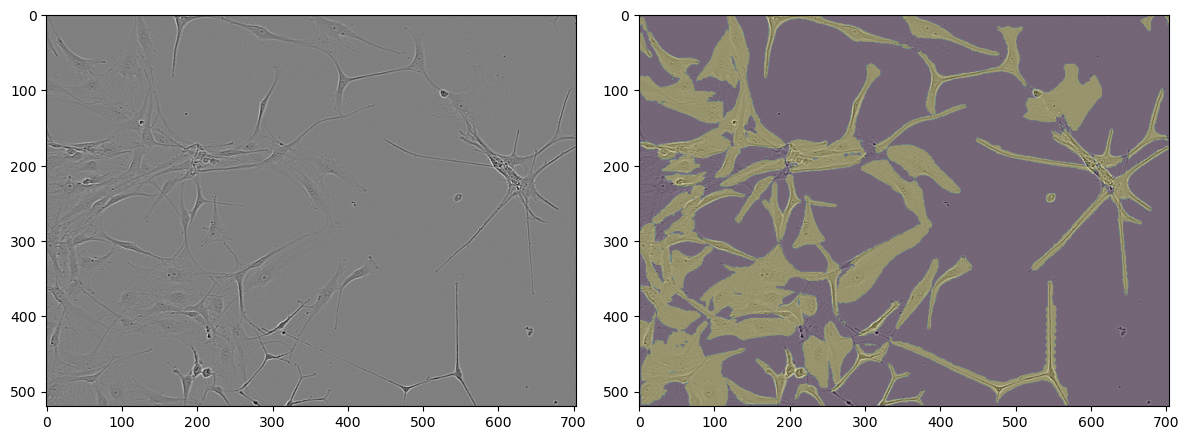

<Figure size 1200x1200 with 0 Axes>

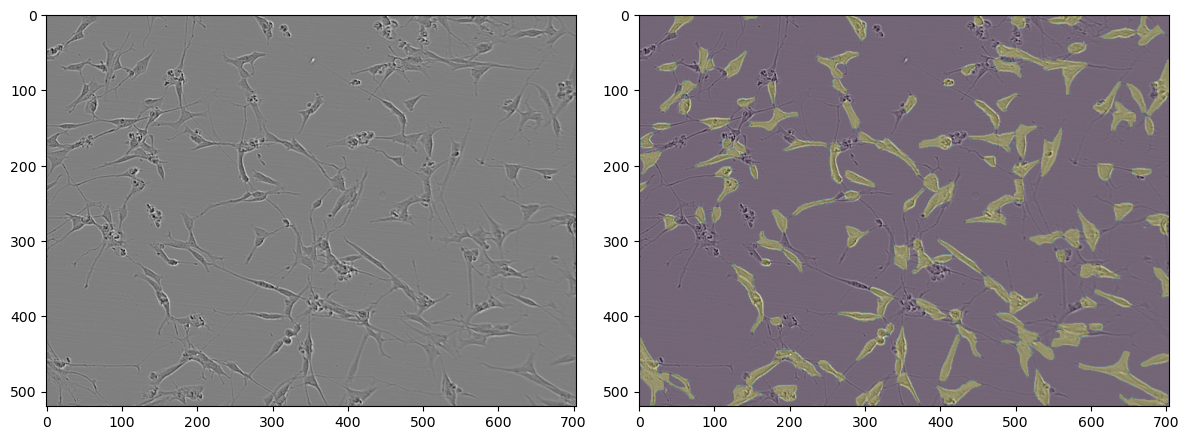

<Figure size 1200x1200 with 0 Axes>

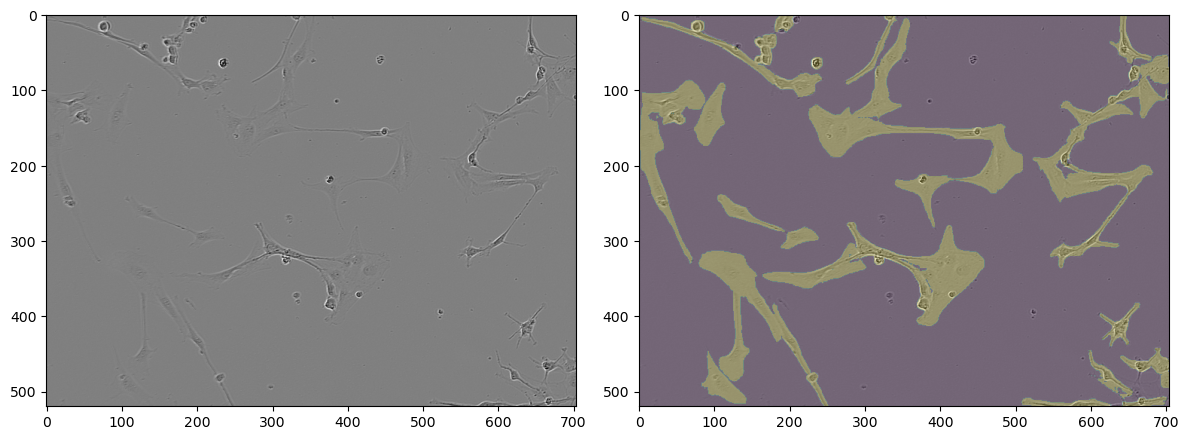

In [49]:
model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=False,
                                                           box_detections_per_img=BOX_DETECTIONS_PER_IMG,
                                                           image_mean=RESNET_MEAN,
                                                           image_std=RESNET_STD)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, CLASSES_NUM)
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, H_LAYER, CLASSES_NUM)

# Load the pre-trained weights
state_dict = torch.load('resnet50_mask-rcnn_model.pth', map_location=torch.device(DEVICE))
model.load_state_dict(state_dict)

# Move the model to the GPU
model.to(DEVICE)

model.eval()  # Set the model to evaluation mode

# mAP = evaluate_model(model, dataloder_train, DEVICE)
# print(f"mAP on train data: {mAP:1.3f}")

submission = []
for sample in dataset_test:
    img = sample['image']
    image_id = sample['image_id']
    with torch.no_grad():
        result = model([img.to(DEVICE)])[0]
    
    previous_masks = []
    for i, mask in enumerate(result["masks"]):
        
        # Filter-out low-scoring results. Not tried yet.
        score = result["scores"][i].cpu().item()
        if score < MIN_SCORE:                   # MIN_SCORE = 0.59
            continue
        
        mask = mask.cpu().numpy()
        # Keep only highly likely pixels
        binary_mask = mask > MASK_THRESHOLD    # MASK_THRESHOLD = 0.5
        binary_mask = remove_overlapping_pixels(binary_mask, previous_masks)
        previous_masks.append(binary_mask)
        rle = rle_encoding(binary_mask)
        submission.append((image_id, rle))
    
    plt.figure(figsize=(12,12))
    ax1 = plt.subplot(121)
    ax1.imshow(img.numpy().transpose((1,2,0)))
    all_preds_masks = np.zeros((HEIGHT, WIDTH))
    for mask in result['masks'].cpu().detach().numpy():
        all_preds_masks = np.logical_or(all_preds_masks, mask[0] > MASK_THRESHOLD)
    ax2 = plt.subplot(122)
    ax2.imshow(img.numpy().transpose((1,2,0)))
    ax2.imshow(all_preds_masks, alpha=0.2)
    plt.tight_layout()
    plt.show()
    
    
    # Add empty prediction if no RLE was generated for this image
    all_images_ids = [image_id for image_id, rle in submission]
    if image_id not in all_images_ids:
        submission.append((image_id, ""))


In [50]:
df_sub = pd.DataFrame(submission, columns=['id', 'predicted'])
df_sub.to_csv( root_address + "/test_predictions.csv", index=False)
df_sub.head()


,id,predicted
0,d8bfd1dafdc4,227117 4 227820 7 228523 9 229227 9 229930 11 ...
1,d8bfd1dafdc4,166762 6 167464 8 168167 9 168871 9 169574 9 1...
2,d8bfd1dafdc4,69687 1 70391 2 71094 4 71797 5 72501 5 73204 ...
3,d8bfd1dafdc4,339442 4 340146 5 340850 6 341555 8 342259 9 3...
4,d8bfd1dafdc4,1526 10 2230 11 2934 11 3638 12 4342 12 5047 1...
